# 06 · 송도 TTC·PET 단변량·이변량 EVT

05의 사건 목록으로 M1·M2의 극값모형을 적합합니다. **사고자료 대조가 없으므로 이 노트북은 모형의 정확도를 판정하지 않습니다.** 같은 추정 대상에서 단변량·이변량 결과가 얼마나 다른지와 그 불확실성을 보여줍니다(AGENTS.md, 08 §7). 2026-09-24 교차 검토 수정 규칙이 기록된 새 05 실행만 읽습니다.

| 단계 | 방법 | 근거 |
|---|---|---|
| 입력 | `X = −minTTC`, `Y = −PET`(후미는 `−minPET`). 역수 변환 없음 | M1 §3.3, 사용자 규칙 |
| 사전선별 | TTC 또는 PET가 4초 미만인 사건. 그 뒤 교차 M1에서 유턴 제외 | M1 PDF p.5, M2 PDF p.3; 흐름 대응 참고 S06 PDF p.8 |
| 층(strata) | 후미추돌(M2 계열)과 교차 **좌회전×대향직진**(M1 계열)을 따로. 지점별 + 전 지점 합산(보조) | 11·12, 두 유형 혼합 금지 |
| 후미 대상 차로 | 기본: 04의 `through_or_shared` 차로(M2 p.3 회전 전용차로 제외). 감도: 접근로 전 차로 | 04 결과: 전용·공용 경계가 뚜렷하지 않음 |
| 자료 오류 제외 | 모든 층: 차체 겹침(`body_overlap`)과 해당 지표 시각의 위치 떨림(`jitter_ttc`, `jitter_pet`, 2D 층은 `jitter_ttc_2d`). 엄격 감도층은 추가로 오토바이가 낀 쌍과, 극값 순간 뒤차가 정지(시속 1km 미만)였던 후미 지표를 뺌. 이 품질·엄격 감도 제외는 PET·TTC 값이 아닌 품질·차종·속력 기준이며, 앞의 사건 사전선별과 구분함 | 12번 "2026-09-24 전수 점검"; 오토바이 제외 참고: Fonod 부록 D; 정지 1km/h: 이 연구의 선택 |
| 임계값 | 기본: 상위 12% 분위(M2 p.5, DuMouchel 1983·Sun 2013). 평균잔차수명·모수 안정성 그림으로 확인하고 필요하면 층별로 바꿈(M1 p.7) | M1·M2 |
| 표본 충분성 | 초과 표본 30개 미만이면 `표본부족` 표시 | M2 p.5 "보통 30개 이상" |
| 단변량 | 일반화 파레토(GPD) 최대우도 | M1 식(2) |
| 이변량 | 로지스틱 이변량 GP, 한쪽만 초과한 관측을 쓰는 **검열우도** | M1 식(7), M2 §4.1 식(11)–(12), Ledford & Tawn 1996 |
| 0초 경계 도달 | 단변량 `Pr(Z≥0)`, 이변량 `Pr(X≥0 또는 Y≥0) = 1 − F(0,0)` | M1 식(9)–(10), M2 §4.2 |
| 불확실성 | 추정 모수의 점근 정규분포에서 5,000번 모의추출한 95% 구간 | M1·M2의 모의추출 절차 |

**같은 대상끼리 비교합니다(08 §7).** 단변량 TTC는 "TTC가 0초에 닿는 사건", 단변량 PET는 "PET가 0초에 닿는 사건", 이변량은 "둘 중 하나라도 닿는 사건"을 추정하므로 서로 다른 값입니다. 그래서 이변량 모형의 **주변(marginal) 확률**을 단변량과 나란히 두고, 두 단변량을 **독립으로 결합한 기준값**을 이변량 OR 확률과 나란히 둡니다. 관측시간당(시간당) 값으로도 나타내며, 관측시간은 05가 파일마다 모든 드론의 관측 시각을 합쳐(합집합) 잰 값입니다.

0초를 넘는 부분은 **사고 쪽으로의 외삽**이지 관측된 사고가 아닙니다. 연(年) 단위 환산은 관측 구간이 1년을 대표한다는 가정이 필요하므로 하지 않습니다.

## 1. 준비

In [12]:
import time as _cell_time
_cell_started = _cell_time.perf_counter()
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.util
import io
import json
import math
import time
import uuid
import warnings

packages = {"pandas": "pandas", "numpy": "numpy", "scipy": "scipy", "matplotlib": "matplotlib", "IPython": "IPython"}
missing = [p for m, p in packages.items() if importlib.util.find_spec(m) is None]
if missing:
    raise ImportError("별도 셀에서 설치하세요: %pip install " + " ".join(missing))
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
print("준비 완료 | pandas", pd.__version__, "| numpy", np.__version__)
print(f"셀 1 경과: {_cell_time.perf_counter() - _cell_started:.2f}초")

준비 완료 | pandas 3.0.5 | numpy 2.4.6
셀 1 경과: 0.00초


## 2. 입력 실행·설정
- **`SOURCE05_ID`에 05 마지막 셀의 실행 ID를 넣으세요.** 04 실행 ID는 채워 두었습니다.
- `PRESCREEN_SECONDS = 4.0`: 정상적인 차량 간 상호작용을 먼저 덜어냅니다. TTC 또는 PET 중 하나가 4초 미만이면 사건을 남기며, 정확히 4초와 계산 불가 값은 미만으로 세지 않습니다(M1 PDF p.5, M2 PDF p.3). 남은 사건의 다른 지표가 4초 이상이어도 잘라내지 않습니다.
- `EXCLUDE_UTURN_M1 = True`: M1은 진입·진출 방향을 지정한 좌회전 대 대향 직진을 다룹니다(M1 PDF p.5). 송도에서는 두 차량 중 하나라도 흐름의 진입·진출 접근로 번호가 같으면 유턴으로 보고 M1에서 제외합니다. 이 대응은 원문의 대상 정의를 송도 흐름 표기에 적용한 것이며, 원문에 동일한 문자열 판정 코드가 있다는 뜻은 아닙니다(S06 PDF p.8 참고). 흐름을 해석할 수 없으면 그 이유로 제외하지 않고 수를 기록합니다.
- 이 4초 선별은 새 송도 수치 기준이 아니라 원문의 사전선별 절차입니다. **사전선별 값**, **EVT 적합 임계값**, **0초 사고 경계**는 서로 다릅니다.
- 유턴을 뺀 뒤 **교차 M1에만 공간 조건**을 적용합니다. 목적 근거는 M1 PDF p.5의 교차로 내 좌회전 대 대향 직진, S06 PDF p.8의 입구·출구 영역, S06 PDF p.17·S01 PDF p.7의 교차점에서 먼 계산 문제입니다. 이 조건만으로 TTC 계산 시각의 모든 위치 오류가 해결되지는 않습니다.
- 기하 근거는 송도 공식 segmentation 차로 다각형과 README입니다. 중앙이 무라벨이므로 차로 다각형을 곧 교차로 영역으로 보지 않습니다. 04의 미터 좌표를 같은 파일의 아핀 역변환으로 Ortho 픽셀에 맞춥니다.
- 구성 절차는 **본 연구의 조작적 정의**입니다: 선별 전 전체 M1 교점의 지점별 중앙값을 방향 기준으로, 차로마다 짧은 변 두 개 중 가까운 변을 고릅니다. 접근로마다 최근접 Section을 고르고 그 Section의 차로 변 끝점으로 볼록 껍질을 만듭니다. 이 절차를 명시한 문헌은 **not_found**입니다. 임의 길이 문턱값이나 새 TTC·PET 기준은 만들지 않습니다.
- 차로 안 `on_lane`을 먼저 제외하고, 중앙 폴리곤 안 `centre`만 남기며, 나머지는 `outside_centre`로 제외합니다. 최신 v2 보완을 적용하므로 0.5m 경계 띠는 수만 기록하고 포함·제외를 바꾸지 않습니다(표시값 문헌 not_found). 공간 판정 불가이면 값을 대체하거나 조용히 제외하지 않고 멈춥니다.
- `intersection_geometry/`에 지점별 전체 M1 분류표, 사용 Section·변·중앙 꼭짓점, 공식 정사영상 확인 그림을 저장합니다. 그림의 점은 **선별 전 전체 M1**, 층 표의 공간 제외 수는 **4초·유턴 제외 뒤 사건**이므로 분모가 다릅니다. 오케스트레이터의 20개 그림 확인이 필요합니다.
- `UPPER_SHARE = 0.12`: 사전선별 뒤 표본의 기본 기준은 상위 12%(M2 PDF p.5), `stable`은 기존 자동 안정 후보를 씁니다. `THRESHOLD_SETS = ["default12", "stable"]` 두 기준을 함께 저장합니다. stable의 자동 판독은 아래에 밝힌 기존 조작적 규칙을 유지하며, M1 PDF p.7의 그림 확인을 대신하지 않습니다.
- 수동 확정값은 `THRESHOLD_OVERRIDE = {"후미_기본|S": {"ttc": -1.5}}`처럼 **유형|지점**으로 넣습니다. 두 기준 모두 수동값이 우선입니다. 값은 음수화한 지표 기준입니다(예: TTC 1.5초 → −1.5). 자동 후보 표와 그림은 그대로 남기고, 실제 적용값·출처를 별도 열로 기록합니다.

In [13]:
import time as _cell_time
_cell_started = _cell_time.perf_counter()
SOURCE04_ID = "20260922T182837Z_4eaba3c7"
SOURCE05_ID = "20260924T125033Z_ffaaff43"  # 05 마지막 셀의 실행 ID
if not SOURCE05_ID:
    raise ValueError("05 노트북 마지막 셀의 실행 ID를 SOURCE05_ID에 입력하세요.")
PROJECT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
                if (p / "AGENTS.md").is_file() and (p / "data/raw").is_dir()), None)
if PROJECT is None:
    raise FileNotFoundError("프로젝트 또는 analysis 폴더에서 실행하세요.")
SOURCE04 = (PROJECT / "data/processed/songdo_structure" / SOURCE04_ID).resolve()
SOURCE05 = (PROJECT / "data/processed/songdo_events" / SOURCE05_ID).resolve()
GEOMETRY_ID = "20260916T134547Z_047caf90"  # 공식 segmentation 차로 폴리곤의 03 실행
GEOMETRY_DIR = (PROJECT / "data/processed/songdo_route_geometry" / GEOMETRY_ID).resolve()
OUTPUT_ROOT = (PROJECT / "data/processed/songdo_evt").resolve()
FPS = 29.97
PRESCREEN_SECONDS = 4.0  # M1 PDF p.5 / M2 PDF p.3: TTC 또는 PET < 4초 사전선별
EXCLUDE_UTURN_M1 = True  # M1 PDF p.5 좌회전 대상 정의를 진입·진출 접근로로 대응; S06 PDF p.8 참고
UPPER_SHARE = 0.12
MIN_EXCEEDANCES = 30
N_SIMULATIONS = 5000
RANDOM_SEED = 20260923
THRESHOLD_OVERRIDE = {}
THRESHOLD_SETS = ["default12", "stable"]
STATIONARY_MPS = 1.0 / 3.6
SITES = list("ABCEFGHIJKLMNOPQRSTU")
print("입력 04:", SOURCE04_ID, "| 입력 05:", SOURCE05_ID)
print(f"셀 2 경과: {_cell_time.perf_counter() - _cell_started:.2f}초")

입력 04: 20260922T182837Z_4eaba3c7 | 입력 05: 20260924T125033Z_ffaaff43
셀 2 경과: 0.00초


## 3. 입력 읽기와 관측시간
- 05가 완료된 실행인지, 같은 녹화 토막·지표별 떨림·교점 중복 처리 등 2026-09-24 수정 규칙을 기록했는지 확인한 뒤 두 사건 목록에서 EVT에 필요한 열만 읽습니다. 수정 전 실행이면 05를 처음부터 다시 실행하라는 안내로 멈춥니다.
- **관측시간**: 05가 파일마다 기록한 `observed_union_s`(모든 드론의 관측 시각을 합친 합집합)의 지점별 합 ÷ 3600. 드론별 시간을 더하면 동시 촬영 구간(전체 0.9시간)을 두 번 세게 되므로 쓰지 않습니다(2026-09-24 점검). 드론별 합과의 차이도 함께 보여줍니다.

In [14]:
LITERATURE_PRESCREEN_SHA256 = '08000d82d5f741c186d7fbaec7b7e2f220ab728c7ac2717f408ba4ead780c060'
SPATIAL_FUNCTION_SHA256 = {'spatial_affine': 'e8c8741f598b653da41200d1219010f8f11753d716df6a2cd15b969bff6a3212', 'spatial_centre_polygon': 'df1d35c90810ef7499e20c070cef9e7e27d2770a7bd77186021325639dcc43ec', 'spatial_classify': 'cd4f69f0e288f8c119a526c6adaefa8bec2a24fbc0172660af87378c0823563b', 'spatial_boundary_distance': '34055d016d4b87479d9b1ad5fd50289743aa6da79083b6618e302032d216a4c8', 'spatial_prepare': 'ad3475b82567ebe3d1893b0f96e45933b64cf8a60fe06ce0cbc807d70947102b', 'spatial_filter': '9df7ba9ae91d14b88658dbb5fe4db6909252ac64aace36257100307f451e4463', 'spatial_save': '90f46864de0e00ae3b6cad0a7ed05a2aafee89e8e9a536b2ca90c04a793ddc93'}
import time as _cell_time
_cell_started = _cell_time.perf_counter()
def now_utc():
    return datetime.now(timezone.utc).isoformat()


def target_path(path):
    path = Path(path).resolve()
    if not path.is_relative_to(RUN_DIR.resolve()):
        raise ValueError("이번 실행 폴더 밖에는 저장하지 않습니다.")
    return path


def save_csv(table, path):
    target = target_path(path)
    temporary = target.with_name(target.name + ".tmp")
    table.to_csv(temporary, index=False, encoding="utf-8-sig")
    temporary.replace(target)


def save_json(value, path):
    target = target_path(path)
    temporary = target.with_name(target.name + ".tmp")
    temporary.write_text(json.dumps(value, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
    temporary.replace(target)


def validate_run_rules(meta):
    required = {
        "recording_break_s": 2.5 / FPS,
        "crossing_pairs_within_recording_chunk": True,
        "jitter_per_indicator": True,
        "crossing_dedup_key": "vehicle_pair_and_raw_segment_pair",
        "bivariate_log_space": True,
        "crossing_ttc_within_recording_chunk": True,
    }
    rules = meta.get("rules")
    forbidden = {"20260923T102351Z_875f4ea7", "20260924T111836Z_ce5dd4cf"}
    if (meta.get("run_id") in forbidden or SOURCE05_ID in forbidden
            or not isinstance(rules, dict)
            or any(rules.get(key) != value for key, value in required.items())):
        raise ValueError("수정 전 실행은 06에 사용할 수 없습니다. 수정된 05를 처음부터 다시 실행하고 새 실행 ID를 입력하세요.")


def literature_prescreen(rear, cross):
    """사건 단위 4초 OR 선별 후 M1 유턴만 제외; 입력과 지표 값은 보존한다."""
    if (isinstance(PRESCREEN_SECONDS, (bool, np.bool_))
            or not np.isfinite(PRESCREEN_SECONDS) or PRESCREEN_SECONDS <= 0):
        raise ValueError("PRESCREEN_SECONDS는 양의 유한한 초 값이어야 합니다.")
    if not isinstance(EXCLUDE_UTURN_M1, (bool, np.bool_)):
        raise ValueError("EXCLUDE_UTURN_M1은 True/False여야 합니다.")

    def selected(table, pet_column):
        ttc = pd.to_numeric(table["min_ttc_s"], errors="coerce")
        pet = pd.to_numeric(table[pet_column], errors="coerce")
        return ((np.isfinite(ttc) & ttc.lt(PRESCREEN_SECONDS))
                | (np.isfinite(pet) & pet.lt(PRESCREEN_SECONDS))).fillna(False)

    rear_keep = selected(rear, "min_pet_s")
    cross_keep = selected(cross, "pet_s")
    m1 = cross["m1_left_turn_opposing_through"].astype(str).str.lower().eq("true")
    uturn = pd.Series(False, index=cross.index)
    invalid_flows = pd.Series(0, index=cross.index, dtype="int64")
    for column in ("flow_a", "flow_b"):
        flow = (cross[column] if column in cross else pd.Series(pd.NA, index=cross.index))
        parts = flow.astype("string").str.extract(r"^\s*([0-9]+)_[0-9]+\s*→\s*([0-9]+)_[0-9]+\s*$")
        valid = parts.notna().all(axis=1)
        same = parts[0].str.lstrip("0").eq(parts[1].str.lstrip("0")).fillna(False)
        uturn |= valid & same
        invalid_flows += (~valid).astype("int64")
    removed_uturn = cross_keep & m1 & uturn & EXCLUDE_UTURN_M1
    rows = []
    groups = [
        (["후미_기본", "후미_기본_엄격", "후미_기본_2DTTC"], rear,
         rear["lane_role"].eq("through_or_shared"), rear_keep, False),
        (["후미_전차로"], rear, pd.Series(True, index=rear.index), rear_keep, False),
        (["교차_M1", "교차_M1_엄격"], cross, m1, cross_keep, True),
    ]
    for names, table, membership, keep, is_cross in groups:
        for site in ["ALL", *sorted(table.loc[membership, "site"].dropna().unique())]:
            before = membership if site == "ALL" else membership & table["site"].eq(site)
            after_screen = before & keep
            removed = int((after_screen & removed_uturn).sum()) if is_cross else 0
            audit = {"지점": site, "선별전_사건": int(before.sum()),
                     "사전선별_제외": int((before & ~keep).sum()),
                     "사전선별후_사건": int(after_screen.sum()), "유턴_제외": removed,
                     "유턴판정불가_사건": int((after_screen & invalid_flows.gt(0)).sum()) if is_cross else 0,
                     "유턴판정불가_흐름": int(invalid_flows.loc[after_screen].sum()) if is_cross else 0,
                     "선별후_사건": int(after_screen.sum()) - removed}
            rows.extend({"유형": name, **audit} for name in names)
    return rear.loc[rear_keep].copy(), cross.loc[cross_keep & ~removed_uturn].copy(), pd.DataFrame(rows)


def spatial_affine(row):
    """07과 같은 EPSG 미터 = A @ Ortho 픽셀 + b 검사와 변환 계약."""
    a = np.array([[row["hand_a11"], row["hand_a12"]], [row["hand_a21"], row["hand_a22"]]], float)
    b = np.array([row["hand_b1"], row["hand_b2"]], float)
    if not np.isfinite(a).all() or not np.isfinite(b).all() or np.linalg.cond(a) > 1e8:
        raise ValueError("유효한 04 아핀 계수가 없습니다.")
    if row["status"] != "completed" or row["hand_local_frame"] != "right_handed":
        raise ValueError("04 완료 상태 또는 EPSG 오른손 좌표계가 확인되지 않았습니다.")
    if not np.isclose(np.linalg.det(a), float(row["hand_det"]), rtol=1e-5, atol=1e-12):
        raise ValueError("04 요약표와 아핀 계수의 행렬식이 다릅니다.")
    return a, b


def spatial_centre_polygon(lanes, anchor):
    """공식 차로의 정지선 쪽 짧은 변 → 접근로별 최근접 Section → 볼록 껍질.

    본 연구의 조작적 정의이며 이 구성 절차 자체의 문헌 근거는 not_found.
    polygon_valid=False도 좌표가 유한하면 사용한다(10 MD 144행).
    """
    from scipy.spatial import ConvexHull, QhullError
    columns = ["tlx", "tly", "blx", "bly", "brx", "bry", "trx", "try"]
    quads, by_section = [], {}
    for row in lanes.to_dict("records"):
        q = np.asarray([row[c] for c in columns], float).reshape(4, 2)
        if not np.isfinite(q).all():
            continue
        quads.append(q)
        if not np.isfinite(anchor).all():
            continue
        section = str(row["Section"])
        approach = section.split("_")[0]
        if not approach.isdigit():
            raise ValueError("접근로 번호를 해석할 수 없는 Section: " + section)
        edges = [(q[i], q[(i + 1) % 4]) for i in range(4)]
        edges.sort(key=lambda e: np.linalg.norm(e[0] - e[1]))
        edge = min(edges[:2], key=lambda e: np.linalg.norm((e[0] + e[1]) / 2 - anchor))
        distance = float(np.linalg.norm((edge[0] + edge[1]) / 2 - anchor))
        by_section.setdefault(section, []).append((distance, edge, str(row["Lane"])))
    best = {}
    for section, edges in by_section.items():
        approach = section.split("_")[0]
        distance = min(e[0] for e in edges)
        if approach not in best or distance < best[approach][0]:
            best[approach] = (distance, section)
    endpoints, used = [], []
    for approach, (distance, section) in best.items():
        for _, edge, lane in by_section[section]:
            endpoints.extend(edge)
            used.append({"approach": approach, "Section": section, "Lane": lane,
                         "section_min_distance_px": distance,
                         "edge_x1": float(edge[0][0]), "edge_y1": float(edge[0][1]),
                         "edge_x2": float(edge[1][0]), "edge_y2": float(edge[1][1])})
    points = np.asarray(endpoints, float).reshape(-1, 2)
    hull, status = np.empty((0, 2)), "insufficient_centre_vertices"
    if len(points) >= 3:
        try:
            hull = points[ConvexHull(points).vertices]
            status = "ok"
        except QhullError:
            status = "degenerate_centre_polygon"
    if not np.isfinite(anchor).all():
        status = "no_finite_m1_anchor"
    return {"quads": quads, "hull": hull, "sections": used, "status": status,
            "anchor": np.asarray(anchor, float)}


def spatial_classify(xy, geometry):
    """최신 SPEC: on_lane 우선, 다음 centre, 나머지 outside_centre. 경계 띠로 변경하지 않음."""
    from matplotlib.path import Path as PolygonPath
    xy = np.asarray(xy, float).reshape(-1, 2)
    result = np.full(len(xy), "invalid_conflict_point", dtype=object)
    valid = np.isfinite(xy).all(axis=1)
    if geometry["status"] != "ok":
        result[valid] = geometry["status"]
        return result
    on_lane = np.zeros(len(xy), bool)
    for quad in geometry["quads"]:
        on_lane |= PolygonPath(quad).contains_points(xy)
    in_centre = PolygonPath(geometry["hull"]).contains_points(xy)
    result[valid] = np.where(on_lane[valid], "on_lane", np.where(in_centre[valid], "centre", "outside_centre"))
    return result


def spatial_boundary_distance(xy, polygons, affine):
    """점과 다각형 변을 같은 04 선형변환으로 미터화. 0.5m는 표시 전용."""
    xy = np.asarray(xy, float).reshape(-1, 2) @ affine.T
    distance = np.full(len(xy), np.inf)
    for polygon in polygons:
        polygon = np.asarray(polygon, float) @ affine.T
        for first, last in zip(polygon, np.roll(polygon, -1, axis=0)):
            delta = last - first
            length2 = float(delta @ delta)
            t = np.zeros(len(xy)) if length2 == 0 else np.clip((xy - first) @ delta / length2, 0, 1)
            distance = np.minimum(distance, np.linalg.norm(xy - (first + t[:, None] * delta), axis=1))
    distance[~np.isfinite(distance)] = np.nan
    return distance


def spatial_prepare(cross, source04, geometry_dir):
    """사전선별 전 전체 M1의 지점별 중앙값을 방향 기준으로 고정한다(시험 원형과 동일)."""
    from pathlib import Path
    import hashlib
    source04, geometry_dir = Path(source04), Path(geometry_dir)
    paths = {"handedness": source04 / "coordinate_handedness_by_file.csv",
             "affine_progress": source04 / "progress.csv", "map_index": geometry_dir / "map_index.csv"}
    provenance = {key: {"path": str(path), "sha256": hashlib.sha256(path.read_bytes()).hexdigest()}
                  for key, path in paths.items()}
    hand, progress, lanes = (pd.read_csv(paths[key]) for key in ("handedness", "affine_progress", "map_index"))
    coefficients = ["hand_a11", "hand_a12", "hand_a21", "hand_a22", "hand_b1", "hand_b2"]
    affines = hand.merge(progress[["source_file", "status"] + coefficients], on="source_file",
                         how="left", validate="one_to_one")
    if affines["file_stem"].duplicated().any():
        raise ValueError("04 아핀 file_stem 중복")
    affines = affines.set_index("file_stem")
    required = {"site", "file_stem", "conflict_x", "conflict_y", "m1_left_turn_opposing_through"}
    if not required.issubset(cross.columns):
        raise ValueError("공간 조건 입력 열 누락: " + str(sorted(required - set(cross.columns))))
    m1 = cross["m1_left_turn_opposing_through"].astype(str).str.lower().eq("true").to_numpy()
    records = cross.loc[m1].copy().reset_index(drop=True)
    records.insert(0, "catalog_row", np.flatnonzero(m1) + 1)  # 07 manifest와 같은 1-based 행
    xy = np.full((len(records), 2), np.nan)
    matrices = {}
    for stem, indices in records.groupby("file_stem", dropna=False).groups.items():
        if stem not in affines.index:
            raise ValueError("04 아핀 파일 미확인: " + str(stem))
        row = affines.loc[stem]
        if not records.loc[indices, "site"].eq(row["site"]).all():
            raise ValueError("05 사건과 04 아핀의 지점 불일치: " + str(stem))
        a, b = spatial_affine(row)
        matrices[stem] = a
        local = records.loc[indices, ["conflict_x", "conflict_y"]].apply(pd.to_numeric, errors="coerce").to_numpy(float)
        xy[indices] = np.linalg.solve(a, (local - b).T).T
    records["ortho_x"], records["ortho_y"] = xy[:, 0], xy[:, 1]
    records["spatial_class"] = "unclassified"
    records["boundary_distance_m"] = np.nan
    geometries, section_rows, vertex_rows, site_rows = {}, [], [], []
    sites = sorted(set(lanes["site"].dropna()) | set(records["site"].dropna()))
    for site in sites:
        indices = records.index[records["site"].eq(site)]
        points = xy[indices]
        finite = points[np.isfinite(points).all(axis=1)]
        anchor = np.median(finite, axis=0) if len(finite) else np.array([np.nan, np.nan])
        geometry = spatial_centre_polygon(lanes.loc[lanes["site"].eq(site)], anchor)
        geometries[site] = geometry
        records.loc[indices, "spatial_class"] = spatial_classify(points, geometry)
        for stem, group in records.loc[indices].groupby("file_stem"):
            records.loc[group.index, "boundary_distance_m"] = spatial_boundary_distance(
                xy[group.index], [*geometry["quads"], geometry["hull"]], matrices[stem])
        section_rows.extend({"site": site, **row} for row in geometry["sections"])
        vertex_rows.extend({"site": site, "vertex": i, "ortho_x": float(p[0]), "ortho_y": float(p[1])}
                           for i, p in enumerate(geometry["hull"]))
        counts = records.loc[indices, "spatial_class"].value_counts()
        site_rows.append({"site": site, "geometry_status": geometry["status"], "all_m1_events": len(indices),
                          "centre": int(counts.get("centre", 0)), "on_lane": int(counts.get("on_lane", 0)),
                          "outside_centre": int(counts.get("outside_centre", 0)),
                          "unclassified": int((~records.loc[indices, "spatial_class"].isin(["centre", "on_lane", "outside_centre"])).sum()),
                          "anchor_x": anchor[0], "anchor_y": anchor[1],
                          "approach_count": len({row["approach"] for row in geometry["sections"]}),
                          "selected_sections": ";".join(dict.fromkeys(row["Section"] for row in geometry["sections"])),
                          "finite_lane_polygons": len(geometry["quads"])})
    # 표시용 0.5m 띠는 분류·잔존 여부에 사용하지 않는다(최신 v2 보완: centre만 잔존).
    records["boundary_near_05m"] = records["boundary_distance_m"].le(0.5)
    annotated = cross.copy()
    classes = np.full(len(cross), "not_m1", dtype=object)
    near = np.zeros(len(cross), bool)
    classes[m1] = records["spatial_class"].to_numpy()
    near[m1] = records["boundary_near_05m"].to_numpy()
    annotated["_m1_spatial_class"], annotated["_m1_boundary_near_05m"] = classes, near
    return annotated, {"events": records, "geometries": geometries,
                       "sections": pd.DataFrame(section_rows), "vertices": pd.DataFrame(vertex_rows),
                       "sites": pd.DataFrame(site_rows), "inputs": provenance}


def spatial_filter(cross, audit):
    """사전선별→유턴 제외 뒤의 M1에만 공간 조건을 적용하고 사건 수를 감사한다."""
    m1 = cross["m1_left_turn_opposing_through"].astype(str).str.lower().eq("true")
    classes = cross["_m1_spatial_class"]
    bad = m1 & ~classes.isin(["centre", "on_lane", "outside_centre"])
    if bad.any():
        raise ValueError("남은 M1 사건의 공간 판정 불가: " + str(classes.loc[bad].value_counts().to_dict()))
    audit = audit.copy()
    audit["유턴제외후_사건"] = audit["선별후_사건"]
    for column in ["공간_on_lane_제외", "공간_outside_centre_제외", "공간_경계근접_표시"]:
        audit[column] = 0
    for index, row in audit.loc[audit["유형"].isin(["교차_M1", "교차_M1_엄격"])].iterrows():
        membership = m1 if row["지점"] == "ALL" else m1 & cross["site"].eq(row["지점"])
        if int(membership.sum()) != row["유턴제외후_사건"]:
            raise ValueError("유턴 제외 뒤 사건 감사표 불일치")
        for label in ["on_lane", "outside_centre"]:
            audit.loc[index, "공간_" + label + "_제외"] = int((membership & classes.eq(label)).sum())
        audit.loc[index, "공간_경계근접_표시"] = int((membership & cross["_m1_boundary_near_05m"]).sum())
        audit.loc[index, "선별후_사건"] = int((membership & classes.eq("centre")).sum())
    return cross.loc[~m1 | classes.eq("centre")].copy(), audit


def spatial_save(context, project, run_dir):
    """중앙 폴리곤·모든 선별 전 M1 분류 점을 공식 정사영상에 표시한다."""
    from pathlib import Path
    from PIL import Image, ImageDraw
    import hashlib
    out = Path(run_dir).resolve() / "intersection_geometry"
    out.mkdir(parents=True, exist_ok=False)
    for name in ["events", "sections", "vertices", "sites"]:
        context[name].to_csv(out / (name + ".csv"), index=False, encoding="utf-8-sig")
    figures = []
    colors = {"centre": "lime", "on_lane": "magenta", "outside_centre": "orange"}
    for site, geometry in context["geometries"].items():
        source = Path(project) / "data/raw/orthophotos/orthophotos" / (str(site) + ".png")
        if not source.is_file():
            raise FileNotFoundError("공식 Ortho 정사영상 없음: " + str(source))
        with Image.open(source) as original:
            original_size = original.size
            picture = original.convert("RGB")
            picture.thumbnail((1600, 1600))  # 표시 해상도이며 분석 수치 기준 아님.
        sx, sy = picture.width / original_size[0], picture.height / original_size[1]
        draw = ImageDraw.Draw(picture)
        def display_points(points):
            return [(float(p[0]) * sx, float(p[1]) * sy) for p in points]
        for quad in geometry["quads"]:
            draw.polygon(display_points(quad), outline="cyan", width=1)
        if len(geometry["hull"]):
            draw.polygon(display_points(geometry["hull"]), outline="white", width=3)
        for row in geometry["sections"]:
            draw.line(display_points([[row["edge_x1"], row["edge_y1"]], [row["edge_x2"], row["edge_y2"]]]), fill="yellow", width=4)
        events = context["events"].loc[context["events"]["site"].eq(site)]
        for row in events.to_dict("records"):
            if not np.isfinite([row["ortho_x"], row["ortho_y"]]).all():
                continue
            x, y = row["ortho_x"] * sx, row["ortho_y"] * sy
            draw.ellipse([x-2, y-2, x+2, y+2], fill=colors.get(row["spatial_class"], "red"))
        count = events["spatial_class"].value_counts()
        header = (f"{site} | all M1 before filters: {len(events)} | " + geometry["status"] + "\n"
                  + " | ".join(f"{key}: {int(count.get(key, 0))}" for key in colors)
                  + "\nwhite: centre hull; yellow: selected edges; cyan: lanes"
                  + "\ngreen: centre; magenta: on_lane; orange: outside_centre"
                  + "\nsections: " + ", ".join(dict.fromkeys(row["Section"] for row in geometry["sections"])))
        draw.rectangle((0, 0, picture.width, 85), fill="black")
        draw.text((8, 5), header, fill="white", spacing=3)
        name = str(site) + "_intersection.png"
        picture.save(out / name)
        figures.append({"site": site, "figure": name, "orthophoto": str(source),
                        "orthophoto_sha256": hashlib.sha256(source.read_bytes()).hexdigest(),
                        "original_width": original_size[0], "original_height": original_size[1]})
    pd.DataFrame(figures).to_csv(out / "figures.csv", index=False, encoding="utf-8-sig")
    return figures


meta05 = json.loads((SOURCE05 / "run_metadata.json").read_text(encoding="utf-8"))
validate_run_rules(meta05)
if meta05.get("status") != "completed" or meta05.get("source04_run_id") != SOURCE04_ID:
    raise ValueError("05가 완료된 실행이 아니거나 04 출처가 다릅니다: " + str(meta05.get("status")))
rear_cols = ["site", "file_stem", "drone_id", "section", "lane", "lane_role", "lane_through_share",
             "leader_id", "follower_id", "ttc_status", "min_ttc_s", "pet_status", "min_pet_s",
             "position_jitter", "jitter_ttc", "jitter_pet", "jitter_ttc_2d", "motorcycle_involved", "follower_speed_at_min_ttc_mps", "follower_speed_at_min_pet_mps",
             "ttc_conflict_type", "pet_conflict_type", "ttc_2d_status", "min_ttc_2d_s", "ttc_2d_conflict_type"]
cross_cols = ["site", "file_stem", "drone_id", "vehicle_a_id", "vehicle_b_id", "crossing_class", "flow_a", "flow_b", "conflict_x", "conflict_y",
              "m1_left_turn_opposing_through", "ttc_status", "min_ttc_s", "pet_status", "pet_s",
              "position_jitter", "jitter_ttc", "jitter_pet", "motorcycle_involved"]
rear = pd.read_csv(SOURCE05 / "event_catalog_rear_end.csv", usecols=rear_cols,
                   dtype={"section": "string", "lane": "string", "drone_id": "string"})
cross = pd.read_csv(SOURCE05 / "event_catalog_crossing.csv", usecols=cross_cols, dtype={"drone_id": "string"})
progress05 = pd.read_csv(SOURCE05 / "progress.csv", keep_default_na=False)
for table in (rear, cross):
    for column in [c for c in ["position_jitter", "jitter_ttc", "jitter_pet", "jitter_ttc_2d", "motorcycle_involved"] if c in table]:
        table[column] = table[column].astype(str).str.lower().eq("true")

if "observed_union_s" not in progress05.columns:
    raise ValueError("05 실행에 합집합 관측시간(observed_union_s)이 없습니다. 수정된 05로 다시 실행하세요.")
done05 = progress05.loc[progress05["status"].eq("completed")]
union_s = pd.to_numeric(done05["observed_union_s"], errors="coerce")
jitter_s = pd.to_numeric(done05["jitter_flag_s"], errors="coerce")
drone_sum_s = pd.to_numeric(done05["observed_drone_sum_s"], errors="coerce")
if union_s.isna().any() or jitter_s.isna().any():
    raise ValueError("관측시간 또는 떨림 시간이 없는 완료 파일이 있습니다.")
hours = ((union_s - jitter_s).groupby(done05["site"]).sum() / 3600).to_dict()
hours["ALL"] = float(sum(hours.values()))
print("사건: 후미추돌", len(rear), "| 교차", len(cross))
cross, spatial_context = spatial_prepare(cross, SOURCE04, GEOMETRY_DIR)
rear, cross, literature_audit = literature_prescreen(rear, cross)
cross, literature_audit = spatial_filter(cross, literature_audit)
print("문헌 절차 후 사건: 후미추돌", len(rear), "| 교차", len(cross))
print("관측시간(드론 합집합 − 위치 떨림 구간):", round(hours["ALL"], 2), "시간 | 뺀 떨림 구간",
      round(float(jitter_s.sum()) / 3600, 3), "시간 | 드론별 합이었다면", round(float(drone_sum_s.sum()) / 3600, 2), "시간")
print(f"셀 3 경과: {_cell_time.perf_counter() - _cell_started:.2f}초")

사건: 후미추돌 481446 | 교차 82296
문헌 절차 후 사건: 후미추돌 381336 | 교차 2932
관측시간(드론 합집합 − 위치 떨림 구간): 137.22 시간 | 뺀 떨림 구간 0.046 시간 | 드론별 합이었다면 138.14 시간
셀 3 경과: 10.02초


## 4. 층(strata) 만들기
각 층은 한 유형·한 지점(또는 전 지점 합산)의 사건입니다. 두 유형과 서로 다른 PET 정의를 한 층에 섞지 않습니다.
층 크기 표의 `선별전_사건 → 사전선별후_사건 → 유턴제외후_사건 → 선별후_사건`은 사건 수입니다. `사전선별_제외`, `유턴_제외`, `공간_on_lane_제외`, `공간_outside_centre_제외`를 순서대로 빼며, 뒤의 지표별 품질 제외와 구분합니다. `공간_경계근접_표시`는 중복될 수 있는 진단 수이며 빼지 않습니다. 유턴 판정 불가 수는 사전선별을 통과한 M1 사건에서 세며, 다른 차량의 유턴이 확인되어 제외된 사건에도 표기 이상이 있으면 포함합니다. 층 전체가 선별로 사라진 지점도 표에는 0건으로 남깁니다.
- `후미_기본`: 후미추돌, `lane_role = through_or_shared`
- `후미_기본_엄격`(감도): 위에서 오토바이가 낀 쌍을 빼고, 극값이 나온 순간 뒤차가 정지(시속 1km 미만, 이 연구의 선택)였던 지표를 뺌
- `후미_기본_2DTTC`(감도): 후미_기본과 같은 사건에서 TTC만 SSAM·S06 방식의 차체 직사각형 2D TTC로 바꿈(PET는 같음)
- `후미_전차로`(감도): 후미추돌, 접근로 전 차로
- `교차_M1`: 교차 중 좌회전×대향직진
- `교차_M1_엄격`(감도): 위에서 오토바이가 낀 쌍을 뺌

모든 층에서 **차체 겹침(`body_overlap`, 자료 오류)**과 **해당 지표 시각의 위치 떨림**은 지표로 쓰지 않습니다(05, 2026-09-24 점검). `jitter_ttc`, `jitter_pet`를 각각 쓰며 2D TTC 층은 `jitter_ttc_2d`를 씁니다. `position_jitter`는 보고용입니다. 후미 층에서는 SSAM 규칙(Gettman 2008 PDF p.46)으로 **차로변경 상충**(`lane_change`)으로 분류된 극값도 뺍니다. 후미추돌 유형이 아니기 때문입니다(사용자 결정 2026-09-24). 엄격 층은 PET·TTC 값이 아니라 차종·속력으로만 거릅니다. 값으로 거르면 추정하려는 꼬리를 스스로 자르게 되기 때문입니다. 기본과 엄격의 차이는 남은 자료 한계(Fonod 부록 D: 오토바이·대형 트럭의 궤적 분리, 정지 상태의 길이 추정 오차)에 결과가 얼마나 민감한지 보여줍니다.

**1 km/h는 우리의 선택입니다.** 이보다 느리면 위치 잡음 때문에 방향을 믿기 어렵다고 보아 사용했습니다. Fonod p.20은 같은 값을 그림을 보기 좋게 하려고 속력을 거를 때 썼을 뿐, 검증된 정지 기준이 아닙니다.

**2026-09-24 교차 검토 반영:** 떨림은 TTC·PET별로 구분하고, 요약표도 각 지표에서 실제로 뺀 수를 따로 셉니다. `떨림_제외_TTC/PET`는 계산된 유한 지표 중 해당 떨림 표시로 첫 단계에서 제외한 수입니다(2D 층의 TTC는 2D 표시만 사용). 작은 α에서도 이변량 우도와 경계 확률이 안정적으로 계산되도록 로그 공간 계산을 쓰고, α의 로지스틱 변환도 지수 넘침을 피합니다. `body_overlap_beyond_u`는 다른 제외 조건을 통과한 겹침 사건 중 해당 지표의 임계값을 넘는 수로, 겹침 제외만의 영향을 보여줍니다.

In [15]:
import time as _cell_time
_cell_started = _cell_time.perf_counter()
def as_negated(table, ttc_col, pet_col, strict=False, speed_cols=None, ttc_status="ttc_status", types=None,
               ttc_jitter="jitter_ttc"):
    ttc = pd.to_numeric(table[ttc_col], errors="coerce")
    pet = pd.to_numeric(table[pet_col], errors="coerce")
    jitter_x_removed = table[ttc_status].eq("computed") & np.isfinite(ttc) & table[ttc_jitter]
    jitter_y_removed = table["pet_status"].eq("computed") & np.isfinite(pet) & table["jitter_pet"]
    eligible_x = ~table[ttc_jitter]
    eligible_y = ~table["jitter_pet"]
    ok_x = table[ttc_status].eq("computed") & eligible_x
    ok_y = table["pet_status"].eq("computed") & eligible_y
    lane_change = pd.Series(False, index=table.index)
    if types is not None:
        lc_x = table[types[0]].eq("lane_change")
        lc_y = table[types[1]].eq("lane_change")
        lane_change = (lc_x & ok_x) | (lc_y & ok_y)
        ok_x &= ~lc_x
        ok_y &= ~lc_y
        eligible_x &= ~lc_x
        eligible_y &= ~lc_y
    base_x, base_y = ok_x.copy(), ok_y.copy()
    moto = table["motorcycle_involved"]
    stopped_x = stopped_y = pd.Series(False, index=table.index)
    if strict:
        ok_x &= ~moto
        ok_y &= ~moto
        eligible_x &= ~moto
        eligible_y &= ~moto
        if speed_cols is not None:
            stopped_x = pd.to_numeric(table[speed_cols[0]], errors="coerce") < STATIONARY_MPS
            stopped_y = pd.to_numeric(table[speed_cols[1]], errors="coerce") < STATIONARY_MPS
            ok_x &= ~stopped_x
            ok_y &= ~stopped_y
            eligible_x &= ~stopped_x
            eligible_y &= ~stopped_y
    x = np.where(ok_x, -ttc, np.nan)
    y = np.where(ok_y, -pet, np.nan)
    ttc_overlap = table[ttc_status].eq("body_overlap")
    pet_overlap = table["pet_status"].eq("body_overlap")
    usable_before = base_x | base_y
    return pd.DataFrame({"site": table["site"].to_numpy(), "x": x, "y": y,
                         "body_overlap": (ttc_overlap | pet_overlap).to_numpy(),
                         "x_overlap": np.where(ttc_overlap & eligible_x, -ttc, np.nan),
                         "y_overlap": np.where(pet_overlap & eligible_y, -pet, np.nan),
                         "jitter_ttc_removed": jitter_x_removed.to_numpy(),
                         "jitter_pet_removed": jitter_y_removed.to_numpy(),
                         "lane_change_removed": lane_change.to_numpy(),
                         "moto_removed": (moto & strict & usable_before).to_numpy(),
                         "stopped_removed": (((stopped_x & base_x) | (stopped_y & base_y)) & ~(moto & strict)).to_numpy()})


rear_base = rear.loc[rear["lane_role"].eq("through_or_shared")]
m1 = cross.loc[cross["m1_left_turn_opposing_through"].astype(str).str.lower().eq("true")]
rear_speeds = ["follower_speed_at_min_ttc_mps", "follower_speed_at_min_pet_mps"]
rear_types = ["ttc_conflict_type", "pet_conflict_type"]
kinds = {
    "후미_기본": as_negated(rear_base, "min_ttc_s", "min_pet_s", types=rear_types),
    "후미_기본_엄격": as_negated(rear_base, "min_ttc_s", "min_pet_s", strict=True, speed_cols=rear_speeds,
                             types=rear_types),
    "후미_기본_2DTTC": as_negated(rear_base, "min_ttc_2d_s", "min_pet_s", ttc_status="ttc_2d_status",
                              types=["ttc_2d_conflict_type", "pet_conflict_type"], ttc_jitter="jitter_ttc_2d"),
    "후미_전차로": as_negated(rear, "min_ttc_s", "min_pet_s", types=rear_types),
    "교차_M1": as_negated(m1, "min_ttc_s", "pet_s"),
    "교차_M1_엄격": as_negated(m1, "min_ttc_s", "pet_s", strict=True),
}
strata = {}
for kind, table in kinds.items():
    strata[(kind, "ALL")] = table
    for site in SITES:
        part = table.loc[table["site"].eq(site)]
        if len(part):
            strata[(kind, site)] = part
summary_rows = [{"유형": k, "지점": s, "사건": len(t), "차체겹침_제외": int(t["body_overlap"].sum()),
                 "떨림_제외_TTC": int(t["jitter_ttc_removed"].sum()),
                 "떨림_제외_PET": int(t["jitter_pet_removed"].sum()),
                 "차로변경_제외": int(t["lane_change_removed"].sum()),
                 "오토바이_제외": int(t["moto_removed"].sum()),
                 "정지_제외": int(t["stopped_removed"].sum()),
                 "TTC있음": int(np.isfinite(t["x"]).sum()),
                 "PET있음": int(np.isfinite(t["y"]).sum()),
                 "둘다": int((np.isfinite(t["x"]) & np.isfinite(t["y"])).sum())} for (k, s), t in strata.items()]
strata_table = pd.DataFrame(summary_rows)
strata_table = literature_audit.merge(strata_table, on=["유형", "지점"], how="outer", validate="one_to_one")
count_columns = ["사건", "차체겹침_제외", "떨림_제외_TTC", "떨림_제외_PET", "차로변경_제외",
                 "오토바이_제외", "정지_제외", "TTC있음", "PET있음", "둘다"]
strata_table[count_columns] = strata_table[count_columns].fillna(0).astype("int64")
assert strata_table["사건"].eq(strata_table["선별후_사건"]).all()
display(strata_table.loc[strata_table["지점"].eq("ALL")])
print(f"셀 4 경과: {_cell_time.perf_counter() - _cell_started:.2f}초")

,유형,지점,선별전_사건,사전선별_제외,사전선별후_사건,유턴_제외,유턴판정불가_사건,유턴판정불가_흐름,선별후_사건,유턴제외후_사건,...,사건,차체겹침_제외,떨림_제외_TTC,떨림_제외_PET,차로변경_제외,오토바이_제외,정지_제외,TTC있음,PET있음,둘다
1,교차_M1,ALL,19432,18416,1016,206,0,0,785,810,...,785,2,2,2,0,0,0,671,783,671
22,교차_M1_엄격,ALL,19432,18416,1016,206,0,0,785,810,...,785,2,2,2,0,188,0,526,595,526
43,후미_기본,ALL,320816,64149,256667,0,0,0,256667,256667,...,256667,818,216,230,20062,0,0,145147,235727,140569
64,후미_기본_2DTTC,ALL,320816,64149,256667,0,0,0,256667,256667,...,256667,921,188,230,17756,0,0,126288,235727,122161
85,후미_기본_엄격,ALL,320816,64149,256667,0,0,0,256667,256667,...,256667,818,216,230,20062,4557,12677,129728,230964,125201
106,후미_전차로,ALL,481446,100110,381336,0,0,0,381336,381336,...,381336,1382,243,278,31318,0,0,228936,347751,221057


셀 4 경과: 0.44초


## 5. 단변량 GPD 함수
- 초과량 `z = 값 − u`에 GPD(σ, ξ)를 최대우도로 맞춥니다. ξ ≤ −1에서는 최대우도가 정의되지 않으므로(Smith 1985) ξ > −1로 제한합니다. 표준오차는 수치 헤시안으로 구하며, 추정값이 이 경계에 닿거나 헤시안이 불안정하면 `ok_no_covariance`로 표시합니다.
- 0초 경계 도달: 초과 사건 중 `Pr(Z ≥ 0 | Z > u) = (1 + ξ(0 − u)/σ)^(−1/ξ)`(ξ<0이고 0이 분포의 끝점보다 크면 0). **관측 기간의 기대 건수 = 초과 수 × 이 확률**이며, 시간당 값은 이것을 관측시간으로 나눈 값입니다. M1 식(9)의 R은 조건부 확률 그 자체입니다.
- 평균잔차수명 그림과 모수 안정성 그림(수정 척도 σ* = σ − ξu, 형상 ξ)을 그려 임계값을 확인합니다(M1 p.7).

In [16]:
import time as _cell_time
_cell_started = _cell_time.perf_counter()
def gpd_nll(params, z):
    log_sigma, xi = params
    if xi <= -1.0:
        return np.inf
    sigma = math.exp(log_sigma)
    if abs(xi) < 1e-8:
        return len(z) * log_sigma + z.sum() / sigma
    t = 1.0 + xi * z / sigma
    if np.any(t <= 0):
        return np.inf
    return len(z) * log_sigma + (1.0 + 1.0 / xi) * np.log(t).sum()


def numerical_hessian(f, x, rel=1e-4):
    x = np.asarray(x, dtype=float)
    n = len(x)
    h = rel * np.maximum(1.0, np.abs(x))
    hess = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            ei = np.zeros(n); ei[i] = h[i]
            ej = np.zeros(n); ej[j] = h[j]
            value = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * h[i] * h[j])
            hess[i, j] = hess[j, i] = value
    return hess


def safe_covariance(hess):
    try:
        cov = np.linalg.inv(hess)
        if np.all(np.isfinite(cov)) and np.all(np.linalg.eigvalsh((cov + cov.T) / 2) > 0):
            return (cov + cov.T) / 2
    except np.linalg.LinAlgError:
        pass
    return None


def fit_gpd(z):
    start = np.array([math.log(max(z.mean(), 1e-6)), 0.1])
    best = None
    for xi0 in (0.1, -0.2, 0.3):
        start[1] = xi0
        result = minimize(gpd_nll, start, args=(z,), method="Nelder-Mead",
                          options={"xatol": 1e-8, "fatol": 1e-10, "maxiter": 4000})
        if np.isfinite(result.fun) and (best is None or result.fun < best.fun):
            best = result
    cov = safe_covariance(numerical_hessian(lambda p: gpd_nll(p, z), best.x))
    return best.x, cov, float(best.fun)


def conditional_boundary_prob(u, sigma, xi, level=0.0):
    z = level - u
    if abs(xi) < 1e-8:
        return math.exp(-z / sigma)
    t = 1.0 + xi * z / sigma
    return 0.0 if t <= 0 else t ** (-1.0 / xi)


def univariate(values, u, fitted=None):
    values = values[np.isfinite(values)]
    exceed = values[values > u] - u
    out = {"n": int(len(values)), "threshold": float(u), "n_exceed": int(len(exceed)),
           "enough_exceedances": bool(len(exceed) >= MIN_EXCEEDANCES)}
    if len(exceed) < 10:
        return {**out, "fit": "too_few"}
    params, cov, nll = fit_gpd(exceed) if fitted is None else fitted
    sigma, xi = math.exp(params[0]), params[1]
    p_cond = conditional_boundary_prob(u, sigma, xi)
    out.update(fit="ok", sigma=sigma, xi=xi, nll=nll, p_boundary_given_exceed=p_cond,
               expected_boundary_events=len(exceed) * p_cond)
    if cov is not None:
        se = np.sqrt(np.diag(cov))
        out.update(se_log_sigma=float(se[0]), se_xi=float(se[1]))
        draws = rng.multivariate_normal(params, cov, size=N_SIMULATIONS)
        sims = np.array([len(exceed) * conditional_boundary_prob(u, math.exp(a), b) for a, b in draws])
        out.update(expected_low=float(np.quantile(sims, 0.025)), expected_high=float(np.quantile(sims, 0.975)))
    else:
        out.update(fit="ok_no_covariance")
    return out


def threshold_diagnostics(values, title=None, path=None):
    """Fit each distinct grid threshold once; keep the original (log sigma, xi) covariance."""
    values = np.sort(np.asarray(values, dtype=float))
    values = values[np.isfinite(values)]
    shares = np.geomspace(0.20, 0.002, 30)
    grid = np.quantile(values, 1 - shares) if len(values) else np.full(len(shares), np.nan)
    rows, fits = [], {}
    for share, u in zip(shares, grid):
        z = values[values > u] - u
        row = {"quantile": 1 - share, "tail_share": share, "u": u, "seconds": -u,
               "n": len(values), "n_exceed": len(z), "fit": "too_few",
               "mrl": float(z.mean()) if len(z) else np.nan,
               "mrl_ci": 1.96 * z.std(ddof=1) / math.sqrt(len(z)) if len(z) > 1 else np.nan,
               "sigma": np.nan, "xi": np.nan, "nll": np.nan, "sigma_star": np.nan,
               "se_xi": np.nan, "se_sigma_star": np.nan,
               "cov_log_sigma": np.nan, "cov_log_sigma_xi": np.nan, "cov_xi": np.nan,
               "comparable": False}
        if len(z) >= MIN_EXCEEDANCES:
            if u not in fits:
                fits[u] = fit_gpd(z)
            params, cov, nll = fits[u]
            sigma, xi = math.exp(params[0]), float(params[1])
            row.update(fit="ok_no_covariance", sigma=sigma, xi=xi, nll=nll, sigma_star=sigma - xi * u)
            if cov is not None:
                # Delta method for sigma*=exp(log_sigma)-xi*u: gradient=(sigma, -u).
                gradient = np.array([sigma, -u])
                var_star = float(gradient @ cov @ gradient)
                if np.all(np.isfinite(cov)) and cov[1, 1] > 0 and var_star > 0:
                    row.update(fit="ok", comparable=True, se_xi=math.sqrt(cov[1, 1]),
                               se_sigma_star=math.sqrt(var_star), cov_log_sigma=cov[0, 0],
                               cov_log_sigma_xi=cov[0, 1], cov_xi=cov[1, 1])
        rows.append(row)
    diagnostics = {"grid": pd.DataFrame(rows), "fits": fits}
    if path is not None:
        candidate = stability_candidate(diagnostics["grid"])
        u_default = float(np.quantile(values, 1 - UPPER_SHARE)) if len(values) else np.nan
        plot_threshold_diagnostics(diagnostics["grid"], title or "", path, u_default, candidate)
    return diagnostics


def stability_candidate(grid):
    """Operational nested-exceedance variance-difference rule; no refitting."""
    enough = grid["n_exceed"].ge(MIN_EXCEEDANCES)
    usable = grid.loc[enough & grid["comparable"]].sort_values("u").drop_duplicates("u")
    out = {"status": "no_stable_region", "u_stable": np.nan, "seconds_stable": np.nan,
           "n_exceed_stable": np.nan, "xi_stable": np.nan, "sigma_stable": np.nan,
           "n_excluded_no_covariance": int((enough & ~grid["comparable"]).sum()),
           "n_below_min_exceedances": int((~enough).sum()), "n_comparable": len(usable),
           "n_higher_compared": 0, "n_candidates_checked": 0,
           "n_undetermined_variance": 0,
           "xi_below_minus_half": int((enough & grid["xi"].lt(-0.5)).sum())}
    # Three HIGHER distinct points require four usable points including the candidate.
    if len(usable) < 4:
        return {**out, "status": "too_few_for_stability"}
    estimates = usable[["xi", "sigma_star"]].to_numpy(float)
    variances = usable[["se_xi", "se_sigma_star"]].to_numpy(float) ** 2
    for i in range(len(usable) - 3):
        row = usable.iloc[i]
        delta_var = variances[i + 1:] - variances[i]
        determined = np.all(np.isfinite(delta_var) & (delta_var > 0), axis=1)
        out["n_candidates_checked"] += 1
        # Count comparison pairs once if either parameter's variance difference is unusable.
        # These comparisons invalidate this candidate; they are never silently dropped.
        out["n_undetermined_variance"] += int((~determined).sum())
        bounds = 1.96 * np.sqrt(np.maximum(delta_var, 0))
        within = np.all(np.abs(estimates[i + 1:] - estimates[i]) <= bounds, axis=1)
        if np.all(determined & within):
            return {**out, "status": "stable", "u_stable": float(row["u"]),
                    "seconds_stable": -float(row["u"]), "n_exceed_stable": int(row["n_exceed"]),
                    "xi_stable": float(row["xi"]), "sigma_stable": float(row["sigma"]),
                    "n_higher_compared": len(usable) - i - 1}
    return out


def threshold_sensitivity(grid, hours):
    """Use cached grid parameters for the unchanged conditional 0-second boundary formula."""
    table = grid.copy()
    table["hours"] = hours
    table["p_boundary_given_exceed"] = np.nan
    table["expected_boundary_events"] = np.nan
    table["per_hour_boundary_events"] = np.nan
    table["sensitivity_status"] = "too_few"
    valid_hours = pd.notna(hours) and np.isfinite(hours) and hours > 0
    for idx, row in table.iterrows():
        if row["n_exceed"] < MIN_EXCEEDANCES:
            continue
        if not np.all(np.isfinite([row["u"], row["sigma"], row["xi"]])) or row["sigma"] <= 0:
            table.loc[idx, "sensitivity_status"] = "invalid_parameters"
            continue
        p = conditional_boundary_prob(row["u"], row["sigma"], row["xi"])
        if not np.isfinite(p) or not 0 <= p <= 1:
            table.loc[idx, "sensitivity_status"] = "invalid_boundary_probability"
            continue
        expected = row["n_exceed"] * p
        table.loc[idx, ["p_boundary_given_exceed", "expected_boundary_events"]] = [p, expected]
        if valid_hours:
            table.loc[idx, "per_hour_boundary_events"] = expected / hours
            table.loc[idx, "sensitivity_status"] = "ok"
        else:
            table.loc[idx, "sensitivity_status"] = "invalid_hours"
    return table


def threshold_plot_title(title, u_default, candidate, label):
    parts = [title]
    if np.isfinite(u_default):
        parts.append(f"기본 {label} ≤ {-u_default:.3g}초")
    if candidate["status"] == "stable":
        parts.append(f"후보 {label} ≤ {candidate['seconds_stable']:.3g}초")
    else:
        parts.append(candidate["status"])
    return " | ".join(parts)


def plot_threshold_diagnostics(grid, title, path, u_default, candidate, label="지표", u_override=None):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
    for ax, column, error, name in zip(axes, ["mrl", "sigma_star", "xi"],
                                     ["mrl_ci", "se_sigma_star", "se_xi"],
                                     ["평균잔차수명", "수정 척도 σ*", "형상 ξ"]):
        ci = grid[error] * (1 if column == "mrl" else 1.96)
        ax.errorbar(grid["u"], grid[column], yerr=ci, fmt="o-", ms=3)
        ax.set_title(name + " (95% 구간)")
        if np.isfinite(u_default):
            ax.axvline(u_default, color="red", lw=1.3, ls="--", label=f"기본: {label} ≤ {-u_default:.3g}초")
        if candidate["status"] == "stable":
            ax.axvline(candidate["u_stable"], color="green", lw=1.3,
                       label=f"자동 후보: {label} ≤ {candidate['seconds_stable']:.3g}초")
        if u_override is not None:
            u_override = float(u_override)
            ax.axvline(u_override, color="purple", lw=1.2, ls=":", label=f"수동: {label} ≤ {-u_override:.3g}초")
        too_few = grid.loc[grid["n_exceed"] < MIN_EXCEEDANCES, "u"]
        ax.plot(too_few, np.full(len(too_few), .03), "x", color="grey", transform=ax.get_xaxis_transform(),
                label=f"초과 {MIN_EXCEEDANCES}개 미만")
        ax.set_xlabel("임계값 u (음수화 지표, 초)")
    axes[0].legend(fontsize=8)
    fig.suptitle(threshold_plot_title(title, u_default, candidate, label))
    fig.tight_layout()
    fig.savefig(target_path(path), dpi=110)
    plt.close(fig)


def plot_threshold_sensitivity(table, title, path, u_default, candidate, label="지표", u_override=None):
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.plot(table["seconds"], table["per_hour_boundary_events"], "o-", ms=3,
            label="격자별 시간당 추정")
    if np.isfinite(u_default):
        ax.axvline(-u_default, color="red", lw=1.3, ls="--", label="기본 12%")
    if candidate["status"] == "stable":
        ax.axvline(candidate["seconds_stable"], color="green", lw=1.3, label="자동 안정 후보")
    if u_override is not None:
        u_override = float(u_override)
        ax.axvline(-u_override, color="purple", lw=1.2, ls=":", label="수동")
    unavailable = table.loc[table["per_hour_boundary_events"].isna(), "seconds"]
    ax.plot(unavailable, np.full(len(unavailable), .03), "x", color="grey",
            transform=ax.get_xaxis_transform(), label="계산 불가(상태는 CSV 확인)")
    ax.invert_xaxis()
    ax.set_xlabel(f"임계값 ({label} ≤ 초; 오른쪽일수록 짧음)")
    ax.set_ylabel("시간당 0초 경계 추정 (건/시간)")
    ax.set_title(threshold_plot_title(title, u_default, candidate, label), fontsize=10)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(target_path(path), dpi=110)
    plt.close(fig)


def validate_threshold_overrides(strata):
    if not isinstance(THRESHOLD_OVERRIDE, dict):
        raise ValueError("THRESHOLD_OVERRIDE는 유형|지점별 사전이어야 합니다.")
    valid_names = {f"{kind}|{site}" for kind, site in strata}
    for name, indicators in THRESHOLD_OVERRIDE.items():
        if name not in valid_names:
            raise ValueError("수동 임계값에 없는 층 이름이 있습니다(유형|지점 확인): " + str(name))
        if not isinstance(indicators, dict):
            raise ValueError("수동 임계값은 ttc/pet별 사전이어야 합니다: " + name)
        for label, value in indicators.items():
            if label not in ("ttc", "pet"):
                raise ValueError("수동 임계값 지표는 소문자 ttc 또는 pet이어야 합니다: " + name + " " + str(label))
            try:
                valid = not isinstance(value, (bool, np.bool_)) and np.isfinite(float(value)) and float(value) < 0
            except (TypeError, ValueError, OverflowError):
                valid = False
            if not valid:
                raise ValueError("수동 임계값은 유한한 음수 초 단위여야 합니다: " + name + " " + label)


def select_threshold(name, label, threshold_set, u_default, candidate):
    override = THRESHOLD_OVERRIDE.get(name, {}).get(label)
    if override is not None:
        override = float(override)
        if not np.isfinite(override) or override >= 0:
            raise ValueError("수동 임계값은 유한한 음수 초 단위여야 합니다: " + name + " " + label)
        return override, "override"
    if threshold_set == "default12":
        return u_default, "default12" if np.isfinite(u_default) else "too_few"
    if threshold_set != "stable":
        raise ValueError("알 수 없는 임계값 기준: " + str(threshold_set))
    return candidate["u_stable"], candidate["status"]

print("단변량 함수 정의 완료")
print(f"셀 5 경과: {_cell_time.perf_counter() - _cell_started:.2f}초")

단변량 함수 정의 완료
셀 5 경과: 0.00초


## 6. 이변량 로지스틱 GP 함수 (검열우도)
M2 §4.1과 Coles(2001) §8.3을 따릅니다.
- 주변분포: 각 지표의 GPD 꼬리와 초과 비율 ζ로 `F(v) = 1 − ζ(1 + ξ(v − u)/σ)^(−1/ξ)`, 이를 단위 Fréchet `z = −1/log F`로 바꿉니다.
- 결합: `G(z₁, z₂) = exp{−(z₁^(−1/α) + z₂^(−1/α))^α}`, α∈(0,1]. α→1은 독립, α→0은 완전 종속입니다.
- 네 영역: 둘 다 임계값 이하(`G(u)`), 한쪽만 초과(`∂G/∂x` 또는 `∂G/∂y`), 둘 다 초과(`∂²G/∂x∂y`).
- 경계: `Pr(X≥0 또는 Y≥0) = 1 − G(z₁(0), z₂(0))`. 같은 모형의 주변 확률 `Pr(X≥0)`, `Pr(Y≥0)`와 독립 결합 `1 − (1 − p_x)(1 − p_y)`도 계산합니다.

In [17]:
import time as _cell_time
_cell_started = _cell_time.perf_counter()
def margin_terms(values, u, sigma, xi, zeta):
    exceed = values > u
    z = np.full(len(values), -1.0 / math.log1p(-zeta))
    log_dz = np.zeros(len(values))
    if exceed.any():
        w = values[exceed] - u
        if abs(xi) < 1e-8:
            tail = zeta * np.exp(-w / sigma)
            dens = zeta / sigma * np.exp(-w / sigma)
        else:
            t = 1.0 + xi * w / sigma
            if np.any(t <= 0):
                return None
            tail = zeta * t ** (-1.0 / xi)
            dens = zeta / sigma * t ** (-1.0 / xi - 1.0)
        if np.any(tail >= 1) or np.any(tail <= 0):
            return None
        log_f = np.log1p(-tail)
        z_ex = -1.0 / log_f
        z[exceed] = z_ex
        log_dz[exceed] = 2.0 * np.log(z_ex) + np.log(dens) - log_f
    return z, log_dz, exceed


def unpack(theta):
    if theta[4] >= 0:
        alpha = 1.0 / (1.0 + math.exp(-theta[4]))
    else:
        exp_theta = math.exp(theta[4])
        alpha = exp_theta / (1.0 + exp_theta)
    return (math.exp(theta[0]), theta[1], math.exp(theta[2]), theta[3], alpha)


def bgp_nll(theta, x, y, ux, uy, zeta_x, zeta_y):
    sx, xx, sy, xy, a = unpack(theta)
    if xx <= -1.0 or xy <= -1.0 or a <= 0.0:
        return np.inf
    mx = margin_terms(x, ux, sx, xx, zeta_x)
    my = margin_terms(y, uy, sy, xy, zeta_y)
    if mx is None or my is None:
        return np.inf
    z1, ld1, e1 = mx
    z2, ld2, e2 = my
    lz1, lz2 = np.log(z1), np.log(z2)
    lp1, lp2 = -lz1 / a, -lz2 / a
    ls = np.logaddexp(lp1, lp2)
    lv = a * ls
    # Logarithms of -V_1, -V_2 and -V_12; avoid intermediate powers.
    lv1 = lp1 - ls + lv - lz1
    lv2 = lp2 - ls + lv - lz2
    lv12 = ((math.log1p(-a) - math.log(a)) if a < 1.0 else -np.inf) + lp1 - ls + lp2 - ls + lv - lz1 - lz2
    ll = -np.exp(lv)
    r10, r01, r11 = e1 & ~e2, ~e1 & e2, e1 & e2
    with np.errstate(divide="ignore", invalid="ignore"):
        ll = ll + np.where(r10, lv1 + ld1, 0.0)
        ll = ll + np.where(r01, lv2 + ld2, 0.0)
        ll = ll + np.where(r11, np.logaddexp(lv1 + lv2, lv12) + ld1 + ld2, 0.0)
    total = ll.sum()
    return -total if np.isfinite(total) else np.inf


def boundary_z(u, sigma, xi, zeta):
    tail = zeta * conditional_boundary_prob(u, sigma, xi)
    if tail <= 0:
        return np.inf, 0.0
    if tail >= 1:
        return 0.0, 1.0
    return -1.0 / math.log1p(-tail), tail


def bgp_boundary(theta, ux, uy, zeta_x, zeta_y):
    sx, xx, sy, xy, a = unpack(theta)
    if a <= 0.0:  # The logistic can underflow to 0; it is outside the model domain.
        return np.nan, np.nan, np.nan, np.nan
    z1, p_x = boundary_z(ux, sx, xx, zeta_x)
    z2, p_y = boundary_z(uy, sy, xy, zeta_y)
    if z1 == 0.0 or z2 == 0.0:
        return 1.0, p_x, p_y, 1.0 - (1.0 - p_x) * (1.0 - p_y)
    log_v = a * np.logaddexp(-math.log(z1) / a, -math.log(z2) / a)
    p_or = -math.expm1(-math.exp(log_v))
    p_ind = -math.expm1(math.log1p(-p_x) + math.log1p(-p_y))
    return p_or, p_x, p_y, p_ind


def bivariate(pairs, ux, uy, start_x, start_y):
    x, y = pairs["x"].to_numpy(float), pairs["y"].to_numpy(float)
    zeta_x, zeta_y = float(np.mean(x > ux)), float(np.mean(y > uy))
    out = {"n_pairs": int(len(x)), "n_exceed_x": int((x > ux).sum()), "n_exceed_y": int((y > uy).sum()),
           "n_exceed_both": int(((x > ux) & (y > uy)).sum()), "zeta_x": zeta_x, "zeta_y": zeta_y}
    if min(out["n_exceed_x"], out["n_exceed_y"]) < 10 or zeta_x >= 1 or zeta_y >= 1:
        return {**out, "fit": "too_few"}
    theta0 = np.array([math.log(start_x[0]), start_x[1], math.log(start_y[0]), start_y[1], 2.0])
    best = None
    for a0 in (2.0, 0.0, -1.0):
        theta0[4] = a0
        result = minimize(bgp_nll, theta0, args=(x, y, ux, uy, zeta_x, zeta_y), method="Nelder-Mead",
                          options={"xatol": 1e-7, "fatol": 1e-9, "maxiter": 8000})
        if np.isfinite(result.fun) and (best is None or result.fun < best.fun):
            best = result
    if best is None:
        return {**out, "fit": "failed"}
    sx, xx, sy, xy, a = unpack(best.x)
    p_or, p_x, p_y, p_ind = bgp_boundary(best.x, ux, uy, zeta_x, zeta_y)
    n = len(x)
    out.update(fit="ok", sigma_x=sx, xi_x=xx, sigma_y=sy, xi_y=xy, alpha=a, nll=float(best.fun),
               expected_or=n * p_or, expected_x=n * p_x, expected_y=n * p_y, expected_or_independent=n * p_ind)
    cov = safe_covariance(numerical_hessian(lambda t: bgp_nll(t, x, y, ux, uy, zeta_x, zeta_y), best.x))
    if cov is None:
        out["fit"] = "ok_no_covariance"
        return out
    draws = rng.multivariate_normal(best.x, cov, size=N_SIMULATIONS)
    sims = np.array([bgp_boundary(d, ux, uy, zeta_x, zeta_y) for d in draws]) * n
    for k, name in enumerate(["or", "x", "y", "or_independent"]):
        out[f"expected_{name}_low"] = float(np.quantile(sims[:, k], 0.025))
        out[f"expected_{name}_high"] = float(np.quantile(sims[:, k], 0.975))
    alpha_draws = 1.0 / (1.0 + np.exp(-draws[:, 4]))
    out.update(alpha_low=float(np.quantile(alpha_draws, 0.025)), alpha_high=float(np.quantile(alpha_draws, 0.975)))
    return out

print("이변량 함수 정의 완료")
print(f"셀 6 경과: {_cell_time.perf_counter() - _cell_started:.2f}초")

이변량 함수 정의 완료
셀 6 경과: 0.00초


## 7. 이번 실행 폴더

In [18]:
import time as _cell_time
_cell_started = _cell_time.perf_counter()
validate_threshold_overrides(strata)
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid.uuid4().hex[:8]
RUN_DIR = (OUTPUT_ROOT / RUN_ID).resolve()
RUN_DIR.mkdir(parents=True, exist_ok=False)
(RUN_DIR / "diagnostics").mkdir()
rng = np.random.default_rng(RANDOM_SEED)
rng_by_threshold_set = {key: np.random.default_rng(RANDOM_SEED) for key in THRESHOLD_SETS}
run_metadata = {"run_id": RUN_ID, "source04_run_id": SOURCE04_ID, "source05_run_id": SOURCE05_ID,
                "started_at_utc": now_utc(), "status": "running", "upper_share": UPPER_SHARE,
                "min_exceedances": MIN_EXCEEDANCES, "n_simulations": N_SIMULATIONS, "seed": RANDOM_SEED,
                "threshold_override": THRESHOLD_OVERRIDE, "crash_data_validation": "not_available",
                "threshold_sets": THRESHOLD_SETS,
                "literature_procedure": {
                    "settings": {"PRESCREEN_SECONDS": PRESCREEN_SECONDS, "EXCLUDE_UTURN_M1": EXCLUDE_UTURN_M1},
                    "function_sha256": LITERATURE_PRESCREEN_SHA256,
                    "spatial": {"version": "stop_line_hull_v2", "geometry_id": GEOMETRY_ID,
                                "function_sha256": SPATIAL_FUNCTION_SHA256,
                                "input_provenance": spatial_context["inputs"],
                                "anchor_population": "all_M1_before_prescreen_and_uturn; site median in Ortho pixels",
                                "order": ["prescreen", "uturn", "spatial_centre_only"],
                                "boundary_display_m": 0.5, "boundary_affects_selection": False,
                                "evidence": {
                                    "purpose": "M1 PDF p.5 좌회전 대 대향 직진의 교차로 내 교차; S06 PDF p.8 입구·출구 영역; S06 PDF p.17 및 S01 PDF p.7 먼 위치 계산 문제",
                                    "geometry": "송도 공식 segmentation 차로 폴리곤 및 README: Ortho(px), Local(EPSG:5186,m); 교차로 중앙은 무라벨",
                                    "construction": "정지선 쪽 짧은 변의 접근로별 최근접 Section → 끝점 볼록 껍질은 M1 정의를 공식 기하로 구현한 본 연구의 조작적 정의; 해당 구성 절차 문헌 not_found",
                                    "boundary": "0.5m는 SPEC의 표시용 값; 문헌 not_found; 최신 보완 centre만 잔존에 따라 제외·포함을 바꾸지 않음"}},
                    "reference_run_id": "20260924T160936Z_7cbe1a82",
                    "criteria": [
                        {"name": "event_prescreen_or", "value": PRESCREEN_SECONDS, "source": "M1 PDF p.5; M2 PDF p.3",
                         "reason": "정상 상호작용을 덜어내기 위해 보유한 TTC·PET 두 지표 중 하나라도 기준 미만인 사건을 남김"},
                        {"name": "exclude_uturn_m1", "value": EXCLUDE_UTURN_M1, "source": "M1 PDF p.5; S06 PDF p.8 (참고)",
                         "reason": "M1 좌회전 대상 정의를 송도 진입·진출 접근로에 대응; 같은 접근로 복귀는 유턴으로 제외"},
                        {"name": "default12_after_prescreen", "value": UPPER_SHARE, "source": "M2 PDF p.5 (사전선별 p.3)",
                         "reason": "정상 상호작용을 제외한 표본에서 기존 12% 꼬리 선택을 적용"},
                        {"name": "stable_after_prescreen", "value": "existing_stable_rule", "source": "M1 PDF p.7; 자동 판독 알고리즘 원문 쪽수 not_found",
                         "reason": "동일한 선별 표본에서 기존 안정 후보를 계산하고 MRL·안정성 그림으로 확인"}]},
                "diagnostic_grid": {"tail_share_start": 0.20, "tail_share_end": 0.002, "points": 30, "spacing": "geometric"},
                "stability_rule": "all higher differences <= 1.96*sqrt(var_higher-var_candidate), both parameters; >=3 higher points",
                "stability_nonpositive_variance": "undetermined comparison; candidate cannot pass",
                "stability_min_higher_points": 3,
                "stability_xi_below_minus_half": "included, counted; Wald approximation may be unreliable",
                "stability_rule_source": "study operational rule; Coles page not_found; visual confirmation required",
                "negation": "X=-minTTC, Y=-PET (rear: -minPET); no inverse transform"}
save_json(run_metadata, RUN_DIR / "run_metadata.json")
save_csv(strata_table, RUN_DIR / "strata_sizes.csv")
save_csv(literature_audit, RUN_DIR / "literature_prescreen_counts.csv")
run_metadata["literature_procedure"]["spatial"]["figures"] = spatial_save(spatial_context, PROJECT, RUN_DIR)
save_json(run_metadata, RUN_DIR / "run_metadata.json")
print("이번 결과 폴더:", RUN_DIR)
print(f"셀 7 경과: {_cell_time.perf_counter() - _cell_started:.2f}초")

이번 결과 폴더: C:\Users\123\Documents\(송도) 교통 연구 논문\data\processed\songdo_evt\20260924T191302Z_4491ed18
셀 7 경과: 15.46초


## 8. 단변량 적합과 임계값 진단
층·지점·지표마다 80%–99.8% 분위의 30점을 봅니다. 초과 비율을 기하 간격(20%→0.2%)으로 줄여 꼬리를 자세히 봅니다. 초과 30개 미만인 점은 회색 ×로 표시하고 적합하지 않습니다. 진단 모수·공분산은 `threshold_diagnostics.csv`에 저장하고 재사용합니다.

**그림 읽는 법.** 왼쪽 평균잔차수명이 대략 직선인지, 가운데 σ*와 오른쪽 ξ가 높은 임계값에서도 비슷한지 봅니다. x축은 `−TTC`·`−PET`이며 오른쪽일수록 짧은 시간입니다. 빨간 점선은 상위 12%, 초록 실선은 자동 안정 후보입니다. 제목과 범례에 원래 초 단위를 함께 씁니다. 후보가 없으면 초록 선을 그리지 않습니다. 수동 확정값은 보라 점선입니다.

**자동 후보 규칙과 한계.** 초과가 30개 이상인 낮은 u부터 검사합니다. 더 높은 모든 비교 가능 격자점 u′에 대해 `|ξ(u′) − ξ(u)| ≤ 1.96 × sqrt(Var ξ(u′) − Var ξ(u))`인지, σ*도 같은 조건을 만족하는지 봅니다. 가장 낮은 통과점을 후보로 택합니다. 위쪽 초과 집합이 아래쪽 집합에 포함되므로 **차이의 분산을 분산의 차로 근사**합니다. 두 분산을 더하거나 낮은 u의 좁은 구간에 위쪽 추정값을 직접 넣는 규칙과 다릅니다. σ* 분산은 `(σ, −u)`와 `(log σ, ξ)` 공분산의 델타 방법으로 구합니다.

공분산 없는 점은 비교에서 빼고 수를 기록합니다. 어느 모수든 분산 차가 0 이하이면 그 비교는 **판정 불가**로 세며 해당 후보는 통과하지 못합니다. 비교점은 후보보다 높은 **서로 다른 u가 최소 3개**여야 합니다(후보를 포함하면 총 4개 이상). 전체 격자에서 이 수를 확보하지 못하면 `too_few_for_stability`, 충분한데 모든 후보가 탈락하면 `no_stable_region`으로 구분합니다. 두 경우 모두 자동 stable 적합은 하지 않습니다. `n_undetermined_variance`는 선택될 때까지(없으면 끝까지) 검사한 후보–위쪽 점 쌍 중 분산 차로 판정 불가인 쌍의 누적 수입니다. ξ < −0.5인 점은 비교에 포함하되 `xi_below_minus_half`에 적합 격자행 수를 기록합니다. 이 영역에서는 헤시안 기반 Wald 근사가 부정확할 수 있습니다.

이 규칙은 **우리의 조작적 규칙**이며 문헌의 확정 알고리즘이 아닙니다. 모수 안정성 원리는 Coles(2001)를 참고하되 로컬 원문 쪽수는 `not_found`입니다. 분산 차 근사·최소 비교점 3개도 이번 연구의 조작 선택이며 관련 문헌 쪽수는 `not_found`입니다. 격자 범위·표본 수·위쪽 점의 잡음·공분산 누락에 따라 후보가 달라질 수 있습니다. 1.96은 정규근사의 점별 95% 비교 기준이며 다중 비교·선택 후 임계값 불확실성이나 동시 신뢰수준을 보장하지 않습니다. **사용자·지도교수가 지점별 그림으로 확인**해야 합니다(M1 p.7). 합산 ALL은 보조입니다.

**임계값 민감도 곡선.** 격자의 기존 σ·ξ로 조건부 0초 경계 확률, `초과 수 × 확률`인 기대 건수, 이를 관측시간으로 나눈 시간당 값을 계산합니다. 재적합 없이 `threshold_sensitivity.csv`에 모든 층을 저장하며 기준별 파일로 나누지 않습니다. 그림의 가로축은 원래 초 단위(오른쪽일수록 짧음), 세로축은 시간당 0초 경계 추정입니다. 모든 그림은 `diagnostics/*_sensitivity.png`에, ALL 그림은 아래에도 보입니다. 계산 불가는 빈 값·상태로 남깁니다. 모형의 유한 끝점이 0초에 못 미쳐 확률이 0인 경우는 계산 불가와 다릅니다. **안정 구간이 없는 층에서는 한 후보 수치보다 이 곡선을 결과 보고의 중심으로 삼습니다.** 사고자료가 없으므로 곡선이나 두 기준의 차이로 정확도를 판단할 수 없습니다.

후보표에는 수동값과 구분한 순수 상위 12%·자동 안정 후보를 남깁니다. 실제 적용값·출처는 `u_applied_*`, `source_*` 열에서 확인합니다. 수동값을 바꾸면 7번부터 다시 실행하세요.

c:\Users\123\AppData\Local\anaconda3\envs\desk\Lib\site-packages\scipy\optimize\_optimize.py:869: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):
c:\Users\123\AppData\Local\anaconda3\envs\desk\Lib\site-packages\scipy\optimize\_optimize.py:869: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):
C:\Users\123\AppData\Local\Temp\ipykernel_31364\3308399184.py:25: RuntimeWarning: invalid value encountered in scalar add
  value = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * h[i] * h[j])
c:\Users\123\AppData\Local\anaconda3\envs\desk\Lib\site-packages\scipy\optimize\_optimize.py:869: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):
c:\Users\123\AppData\Local\anaconda3\envs\desk\Lib\site-packages\scipy\optimize\_optimize.py:869: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fs

default12 단변량 결과


,유형,지점,지표,threshold_set,threshold_source,hours,threshold,n,body_overlap_beyond_u,n_exceed,...,nll,p_boundary_given_exceed,expected_boundary_events,se_log_sigma,se_xi,expected_low,expected_high,per_hour_boundary_events,per_hour_low,per_hour_high
0,후미_기본,ALL,ttc,default12,default12,137.21562,-2.11302,145147,370,17418,...,131.76531,0.00029,5.05687,0.00927,0.00543,3.34629,7.18536,0.03685,0.02439,0.05237
1,후미_기본,ALL,pet,default12,default12,137.21562,-0.91102,235727,594,28288,...,-15884.84277,0.00124,35.10832,0.00742,0.00463,27.75688,43.27234,0.25586,0.20229,0.31536
42,후미_기본_엄격,ALL,ttc,default12,default12,137.21562,-2.07969,129728,153,15568,...,-1223.78652,0.00008,1.19194,0.00947,0.00516,0.65258,1.96817,0.00869,0.00476,0.01434
43,후미_기본_엄격,ALL,pet,default12,default12,137.21562,-0.91849,230964,293,27716,...,-15825.31045,0.00121,33.53269,0.00751,0.00469,26.41423,41.49326,0.24438,0.19250,0.30239
84,후미_기본_2DTTC,ALL,ttc,default12,default12,137.21562,-2.04257,126288,385,15155,...,-1042.84860,0.00025,3.71359,0.00993,0.00579,2.40492,5.44065,0.02706,0.01753,0.03965
85,후미_기본_2DTTC,ALL,pet,default12,default12,137.21562,-0.91102,235727,594,28288,...,-15884.84277,0.00124,35.10832,0.00742,0.00463,27.82691,43.11151,0.25586,0.20280,0.31419
126,후미_전차로,ALL,ttc,default12,default12,137.21562,-2.08184,228936,636,27473,...,651.94312,0.00047,12.88891,0.00752,0.00456,9.62151,16.58479,0.09393,0.07012,0.12087
127,후미_전차로,ALL,pet,default12,default12,137.21562,-0.91838,347751,1031,41730,...,-22963.16010,0.00135,56.47789,0.00616,0.00390,46.72846,66.89860,0.41160,0.34055,0.48754
168,교차_M1,ALL,ttc,default12,default12,137.21562,-2.51624,671,2,81,...,5.58424,0.00000,0.00000,0.13375,0.08204,0.00000,0.00020,0.00000,0.00000,0.00000
169,교차_M1,ALL,pet,default12,default12,137.21562,-2.77137,783,0,94,...,49.40705,0.00000,0.00000,0.11706,0.07433,0.00000,0.00000,0.00000,0.00000,0.00000


stable 단변량 결과


,유형,지점,지표,threshold_set,threshold_source,hours,threshold,n,fit,enough_exceedances,...,nll,p_boundary_given_exceed,expected_boundary_events,se_log_sigma,se_xi,expected_low,expected_high,per_hour_boundary_events,per_hour_low,per_hour_high
0,후미_기본,ALL,ttc,stable,no_stable_region,137.21562,NaN,145147,no_stable_region,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,후미_기본,ALL,pet,stable,no_stable_region,137.21562,NaN,235727,no_stable_region,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,후미_기본_엄격,ALL,ttc,stable,no_stable_region,137.21562,NaN,129728,no_stable_region,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43,후미_기본_엄격,ALL,pet,stable,no_stable_region,137.21562,NaN,230964,no_stable_region,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84,후미_기본_2DTTC,ALL,ttc,stable,no_stable_region,137.21562,NaN,126288,no_stable_region,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
85,후미_기본_2DTTC,ALL,pet,stable,no_stable_region,137.21562,NaN,235727,no_stable_region,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126,후미_전차로,ALL,ttc,stable,no_stable_region,137.21562,NaN,228936,no_stable_region,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127,후미_전차로,ALL,pet,stable,no_stable_region,137.21562,NaN,347751,no_stable_region,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,교차_M1,ALL,ttc,stable,stable,137.21562,-2.76155,671,ok,True,...,27.93860,0.0,0.0,0.10772,0.06308,0.0,0.0,0.0,0.0,0.0
169,교차_M1,ALL,pet,stable,stable,137.21562,-3.18366,783,ok,True,...,95.89232,0.0,0.0,0.09593,0.05978,0.0,0.0,0.0,0.0,0.0


ALL 자동 후보(수동 적용 여부와 별도)


,유형,지점,지표,n,u_default12,seconds_default12,n_exceed_default12,xi_default12,status,u_stable,...,n_below_min_exceedances,n_comparable,n_higher_compared,n_candidates_checked,n_undetermined_variance,xi_below_minus_half,u_applied_default12,source_default12,u_applied_stable,source_stable
0,후미_기본,ALL,ttc,145147,-2.11302,2.11302,17418,-0.13156,no_stable_region,NaN,...,0,30,0,27,122,5,-2.11302,default12,NaN,no_stable_region
1,후미_기본,ALL,pet,235727,-0.91102,0.91102,28288,-0.22334,no_stable_region,NaN,...,0,25,0,22,50,8,-0.91102,default12,NaN,no_stable_region
42,후미_기본_엄격,ALL,ttc,129728,-2.07969,2.07969,15568,-0.13524,no_stable_region,NaN,...,0,30,0,27,37,1,-2.07969,default12,NaN,no_stable_region
43,후미_기본_엄격,ALL,pet,230964,-0.91849,0.91849,27716,-0.21314,no_stable_region,NaN,...,0,25,0,22,43,8,-0.91849,default12,NaN,no_stable_region
84,후미_기본_2DTTC,ALL,ttc,126288,-2.04257,2.04257,15155,-0.11888,no_stable_region,NaN,...,0,30,0,27,105,4,-2.04257,default12,NaN,no_stable_region
85,후미_기본_2DTTC,ALL,pet,235727,-0.91102,0.91102,28288,-0.22334,no_stable_region,NaN,...,0,25,0,22,50,8,-0.91102,default12,NaN,no_stable_region
126,후미_전차로,ALL,ttc,228936,-2.08184,2.08184,27473,-0.12996,no_stable_region,NaN,...,0,30,0,27,165,6,-2.08184,default12,NaN,no_stable_region
127,후미_전차로,ALL,pet,347751,-0.91838,0.91838,41730,-0.22172,no_stable_region,NaN,...,0,25,0,22,59,8,-0.91838,default12,NaN,no_stable_region
168,교차_M1,ALL,ttc,671,-2.51624,2.51624,81,-0.31002,stable,-2.76155,...,20,10,8,2,1,0,-2.51624,default12,-2.76155,stable
169,교차_M1,ALL,pet,783,-2.77137,2.77137,94,-0.48095,stable,-3.18366,...,19,11,9,2,1,4,-2.77137,default12,-3.18366,stable


지점별 요약(ALL 제외)


,유형,지표,지점수,안정후보_지점수
0,교차_M1,pet,19,0
1,교차_M1,ttc,19,0
2,교차_M1_엄격,pet,19,0
3,교차_M1_엄격,ttc,19,0
4,후미_기본,pet,20,10
5,후미_기본,ttc,20,14
6,후미_기본_2DTTC,pet,20,10
7,후미_기본_2DTTC,ttc,20,15
8,후미_기본_엄격,pet,20,9
9,후미_기본_엄격,ttc,20,17


진단·두 기준 단변량 적합 완료 (220초)


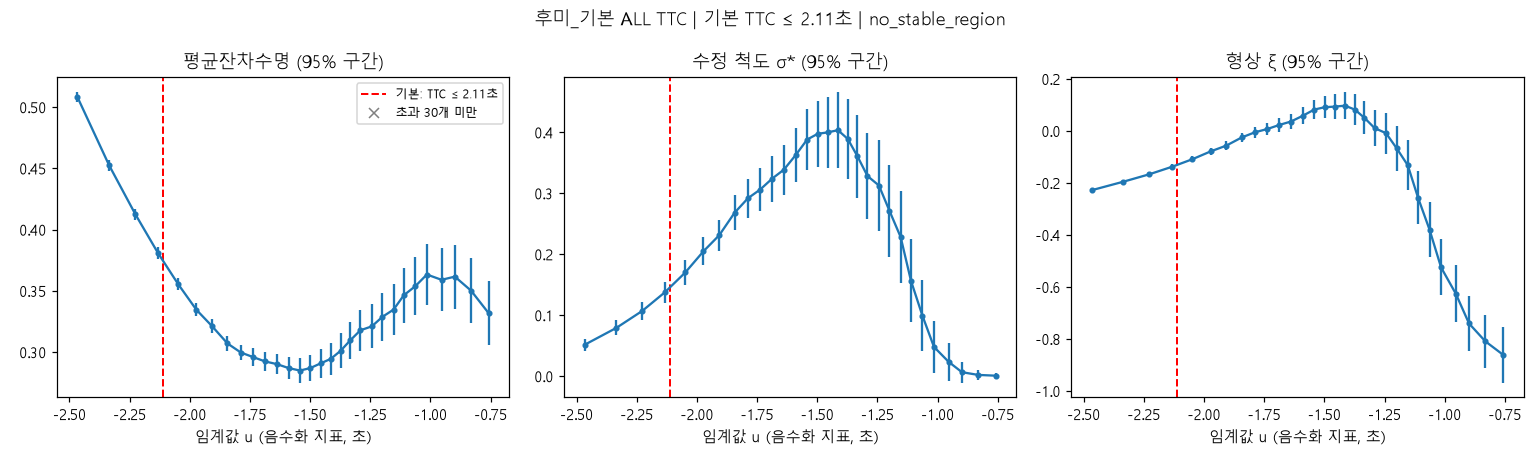

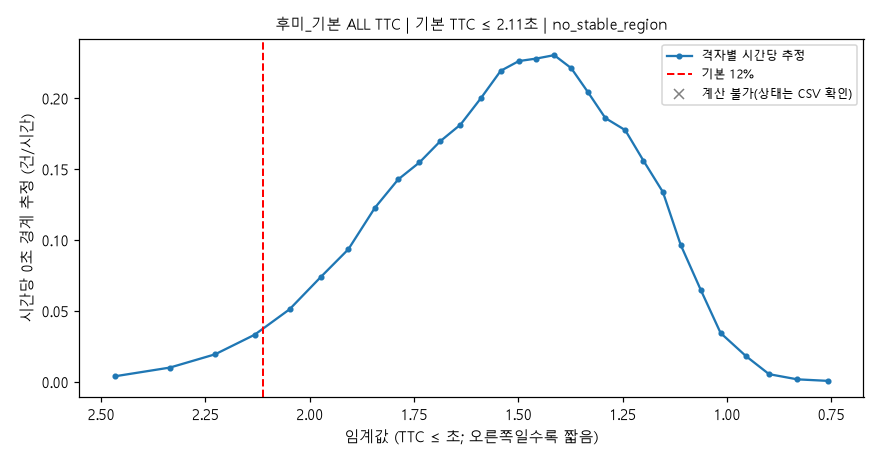

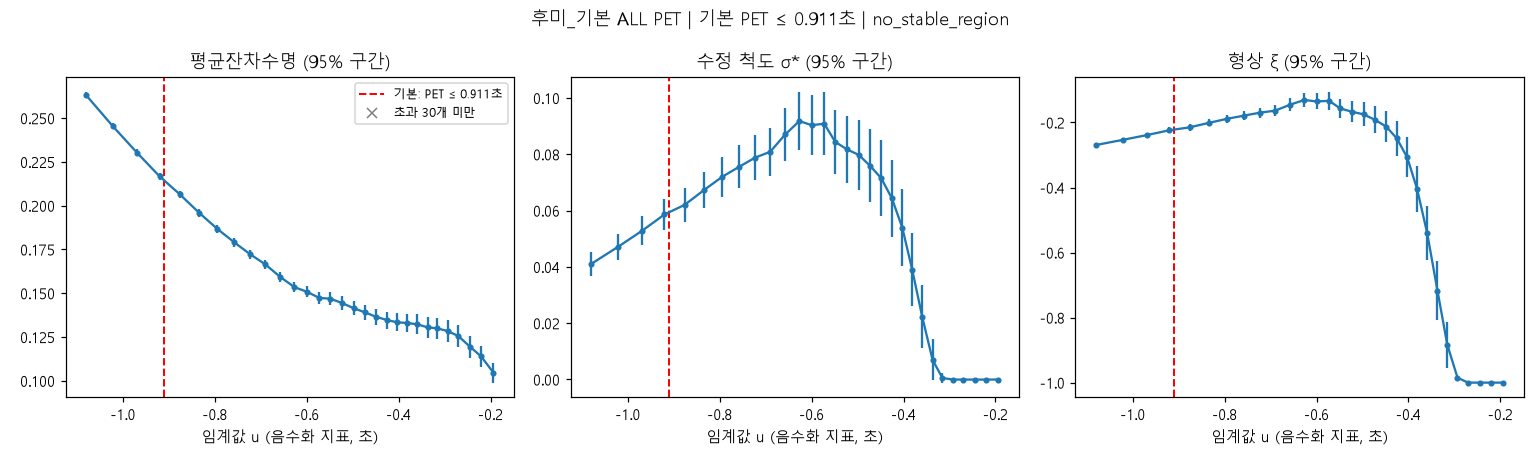

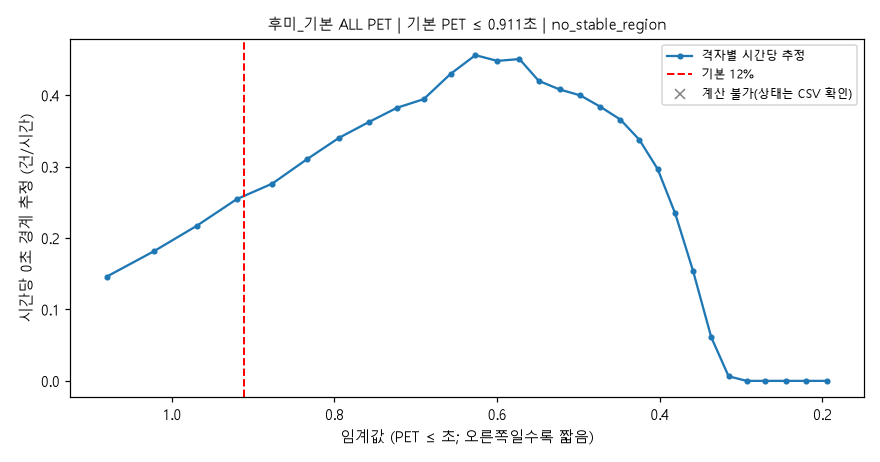

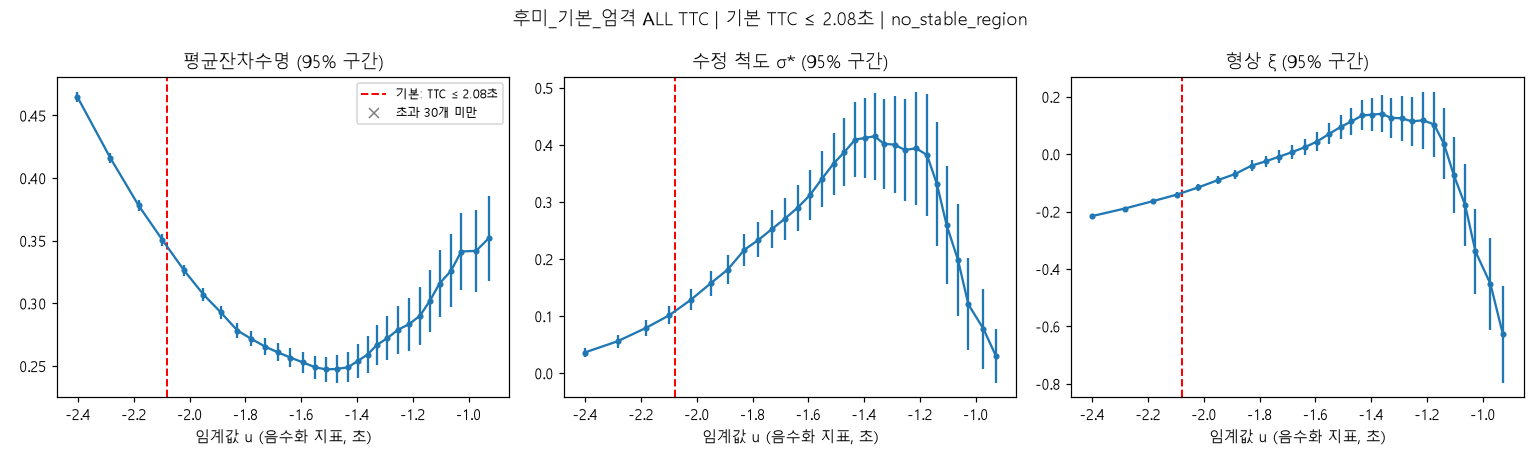

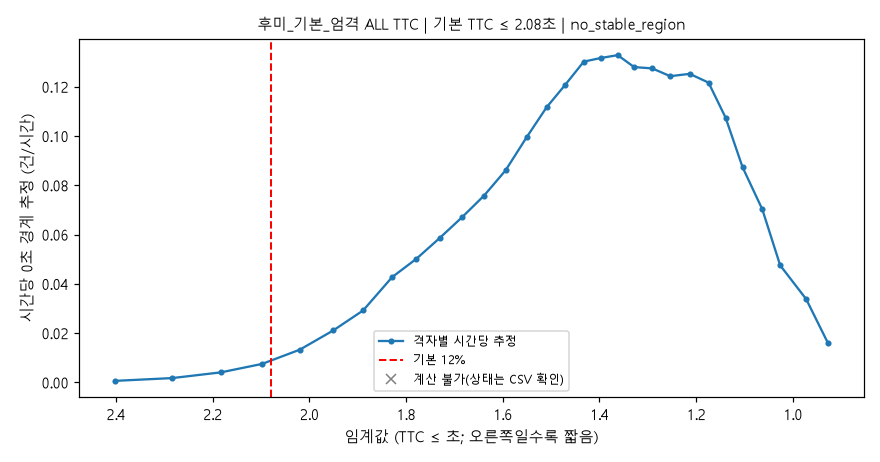

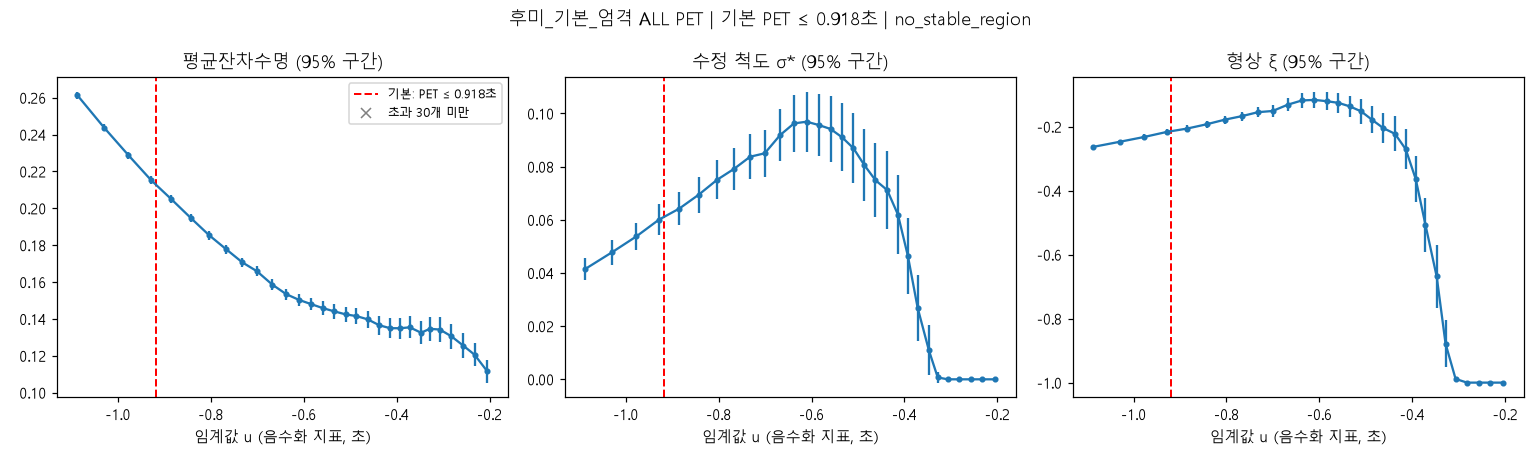

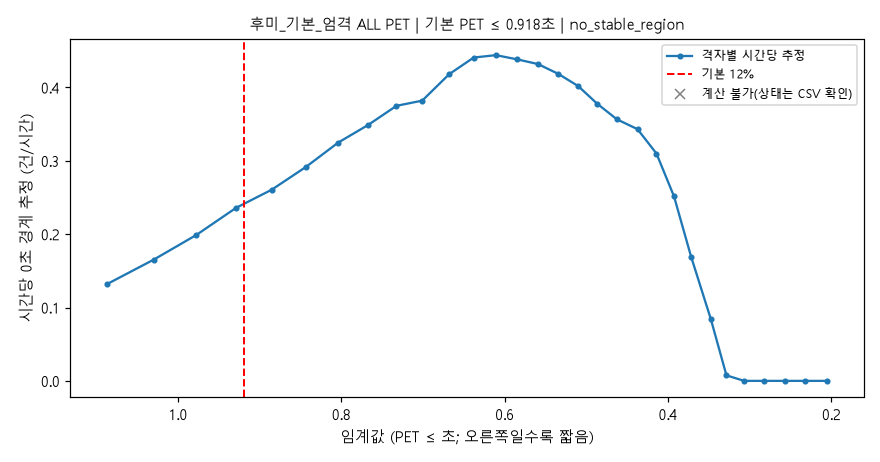

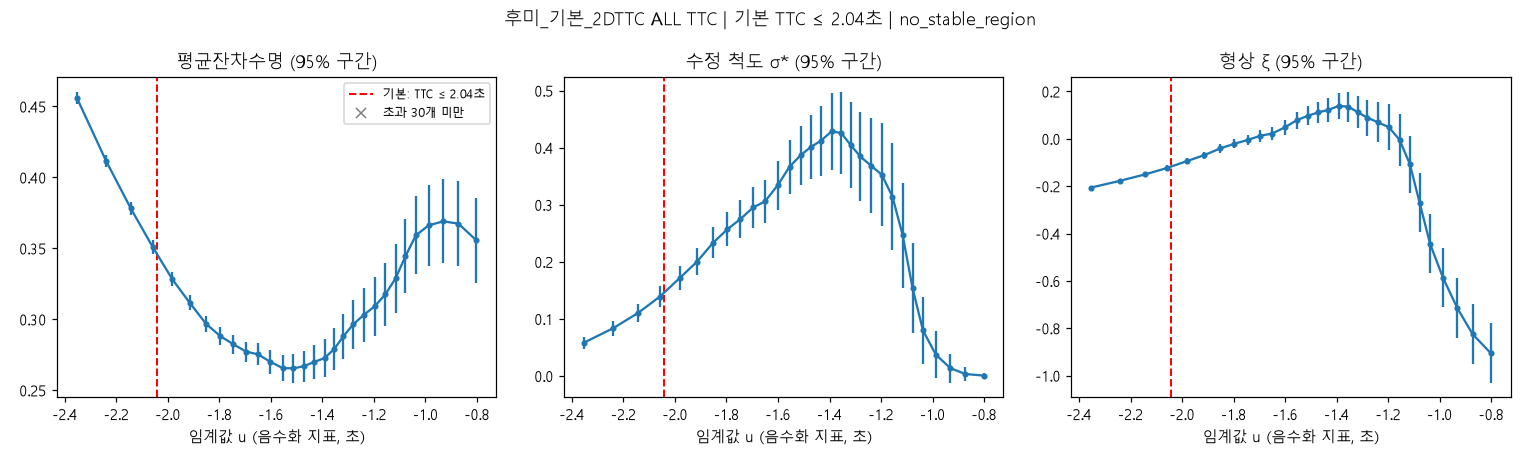

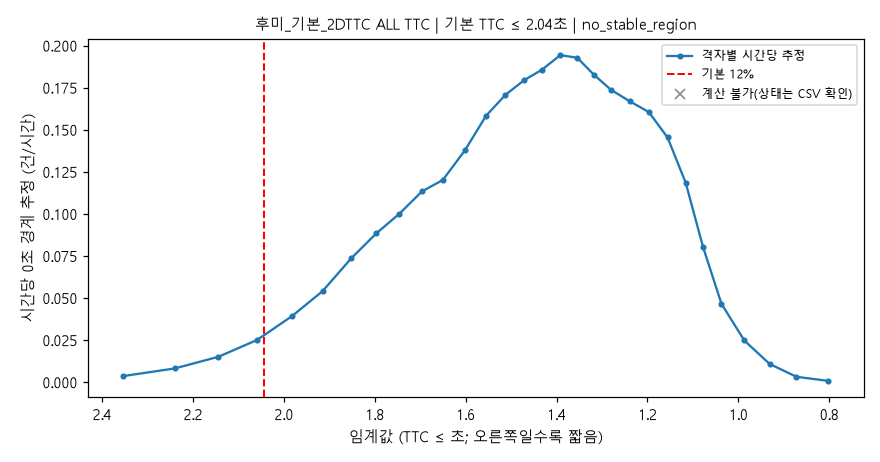

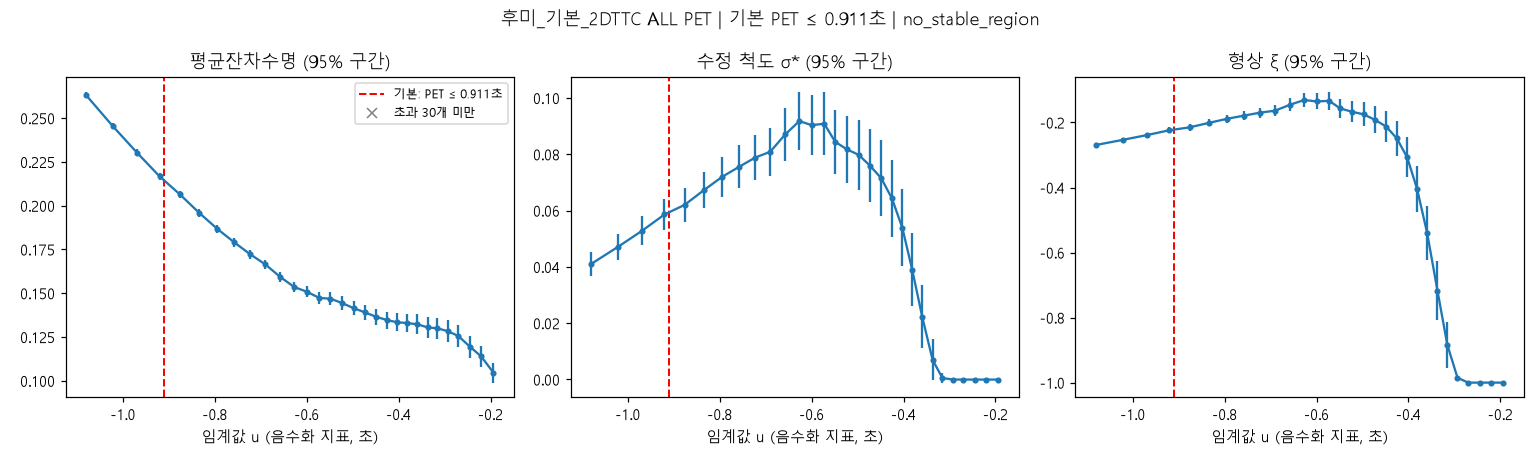

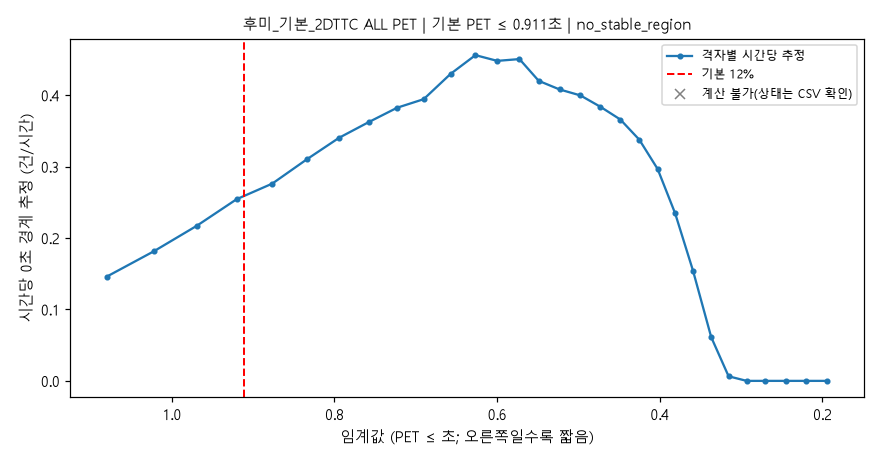

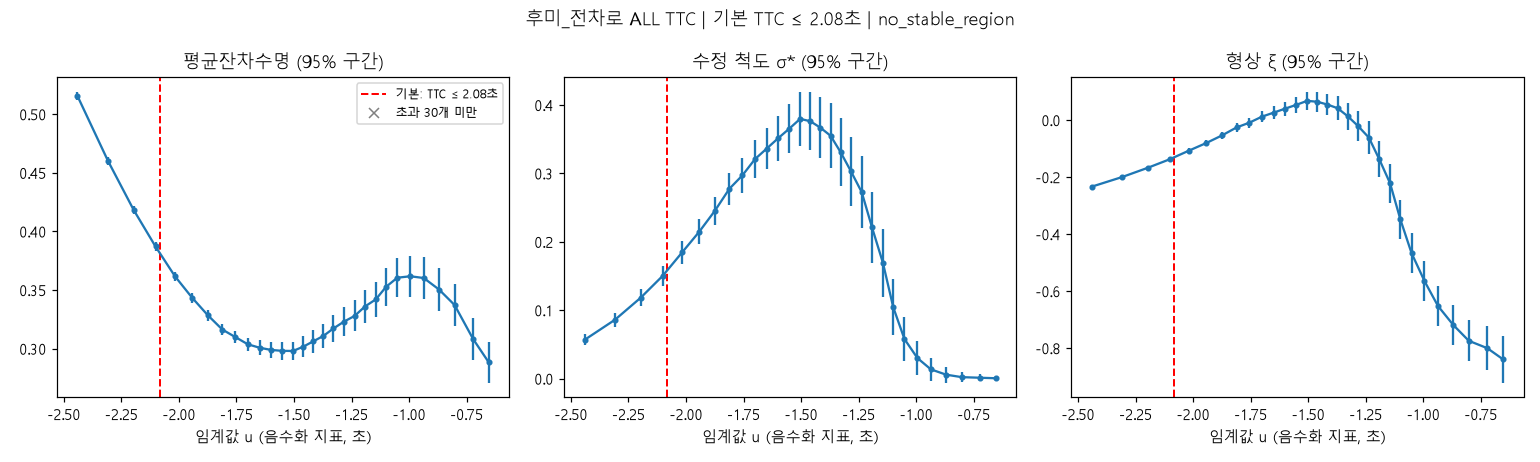

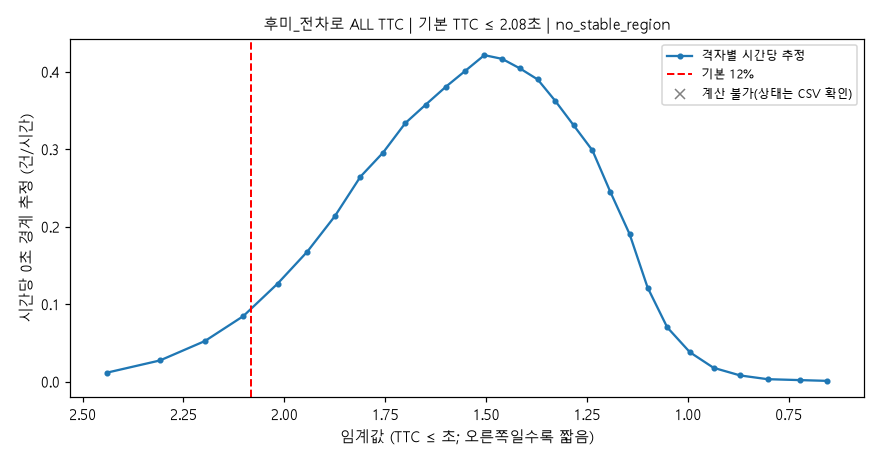

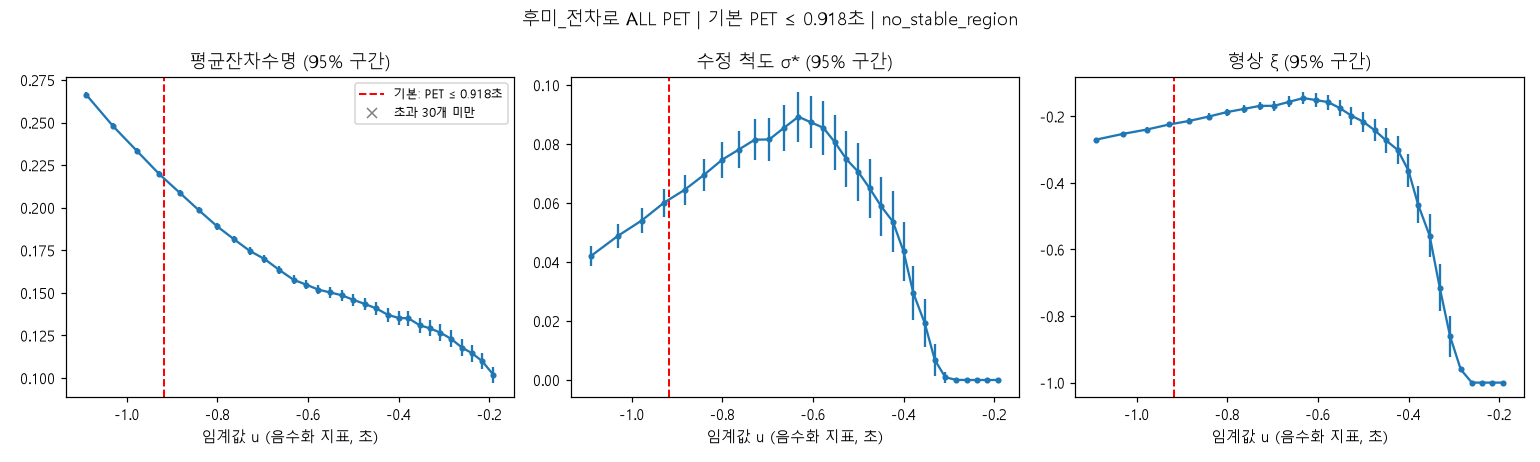

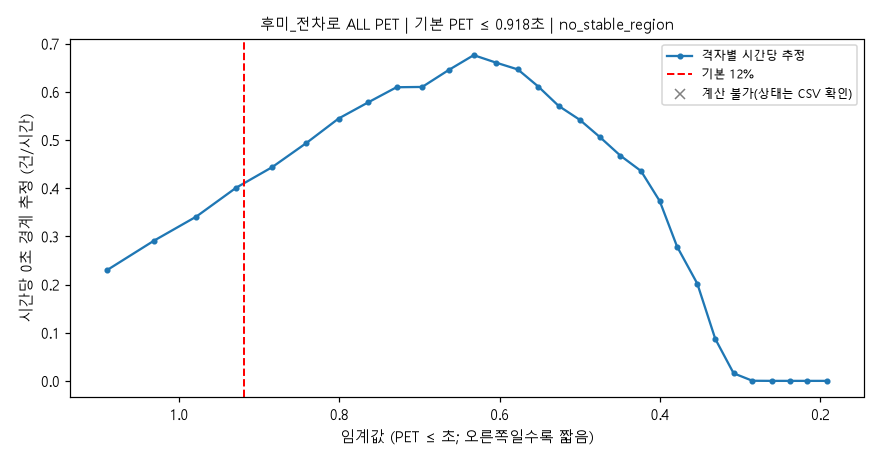

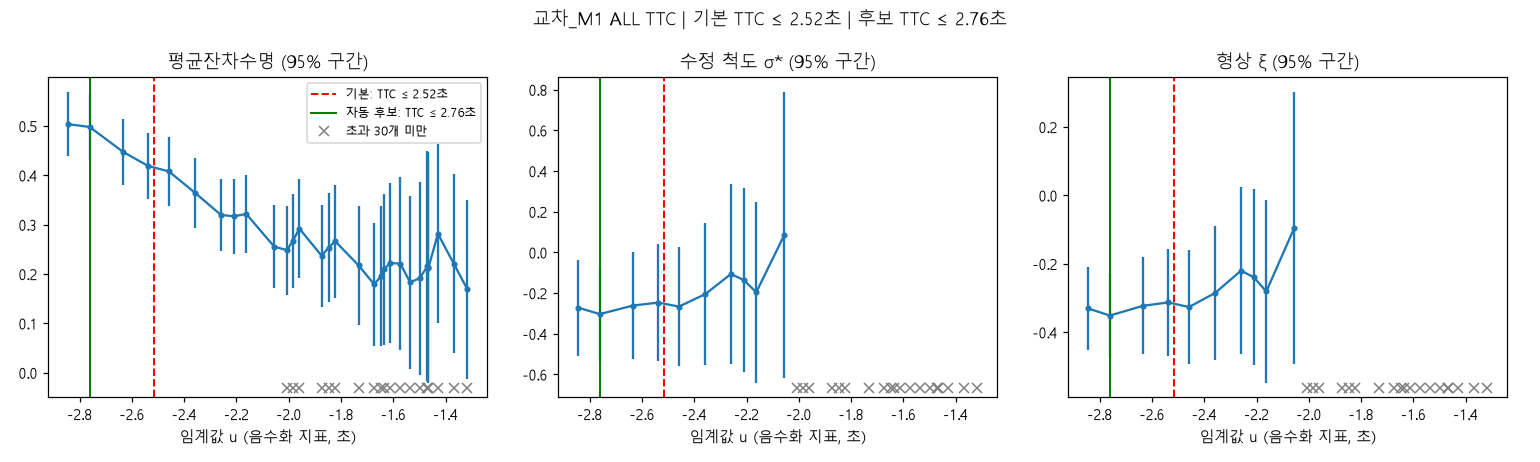

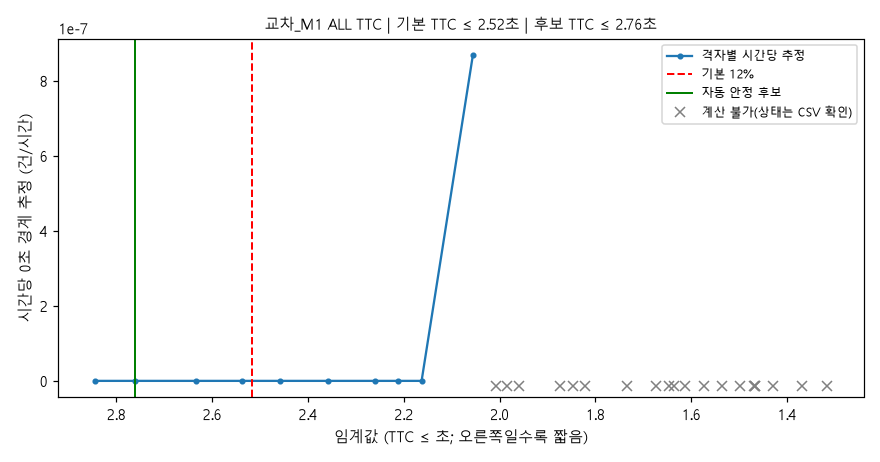

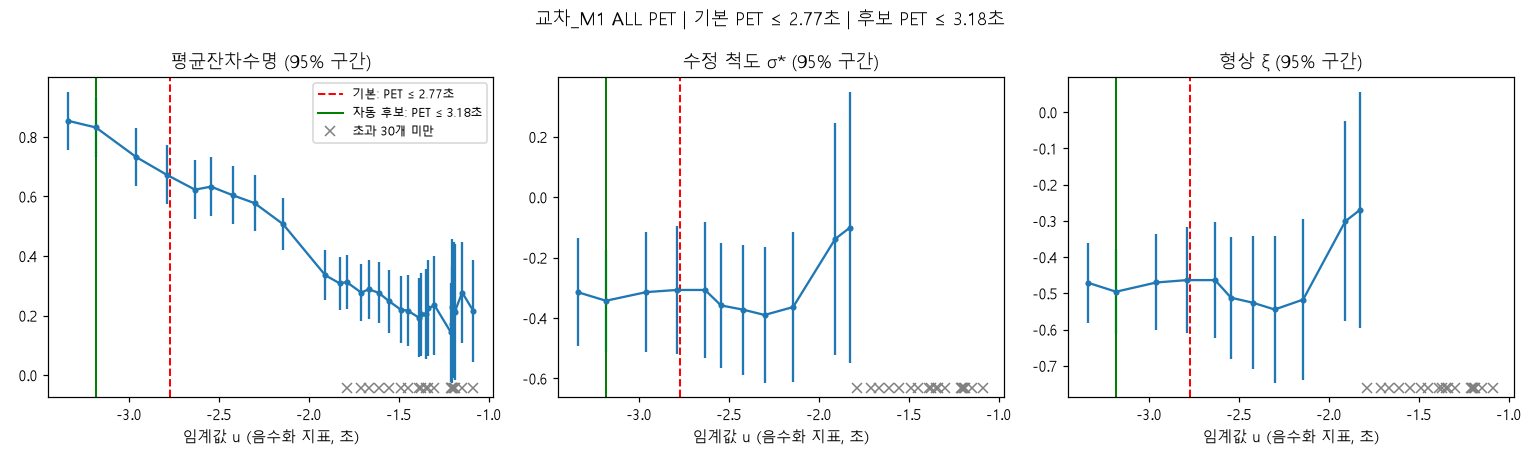

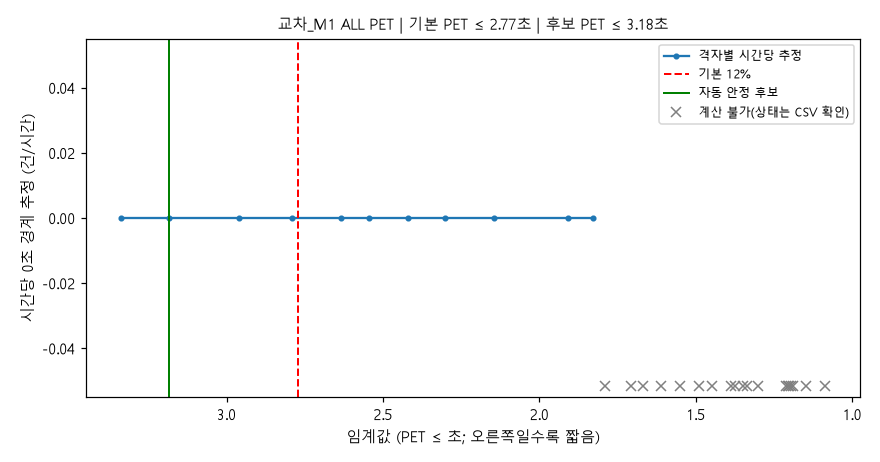

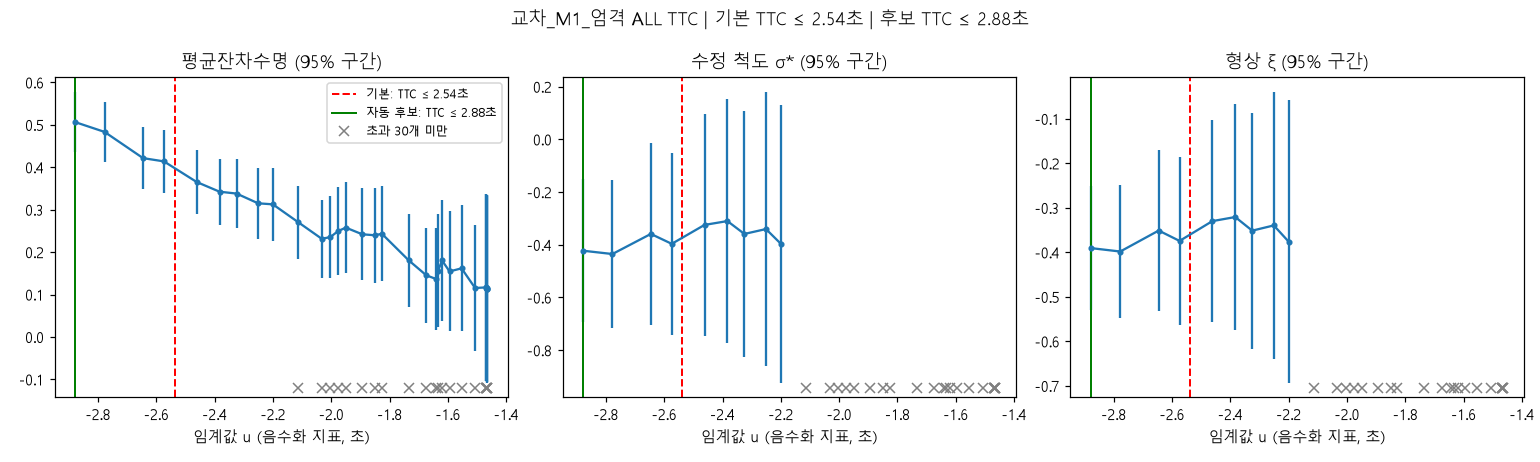

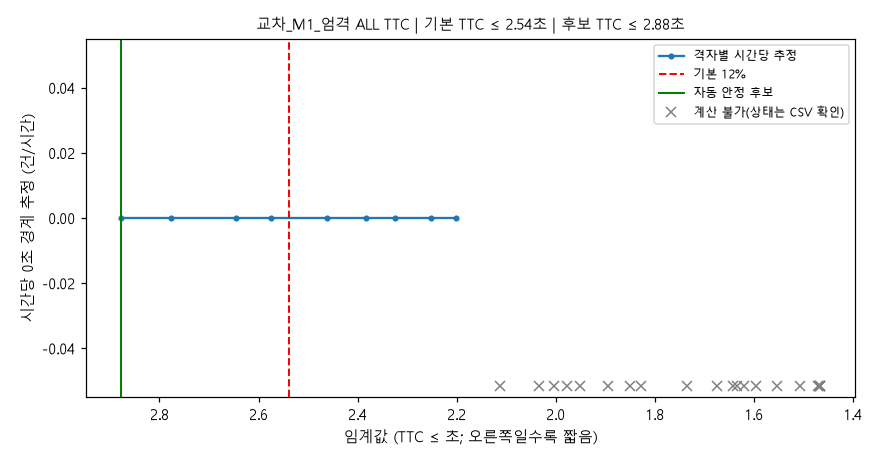

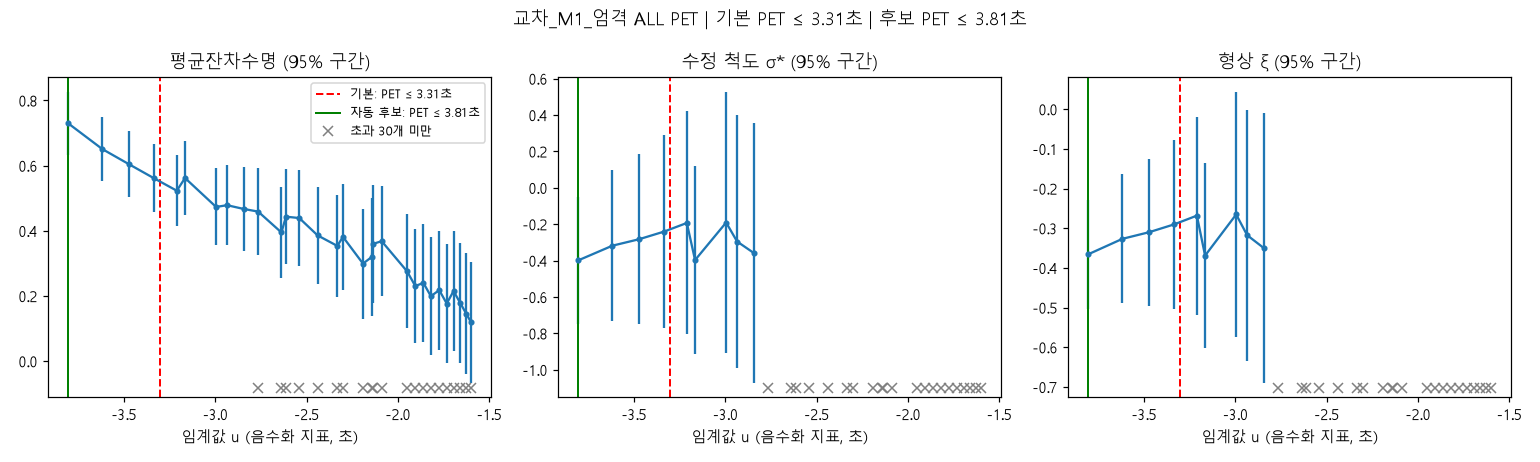

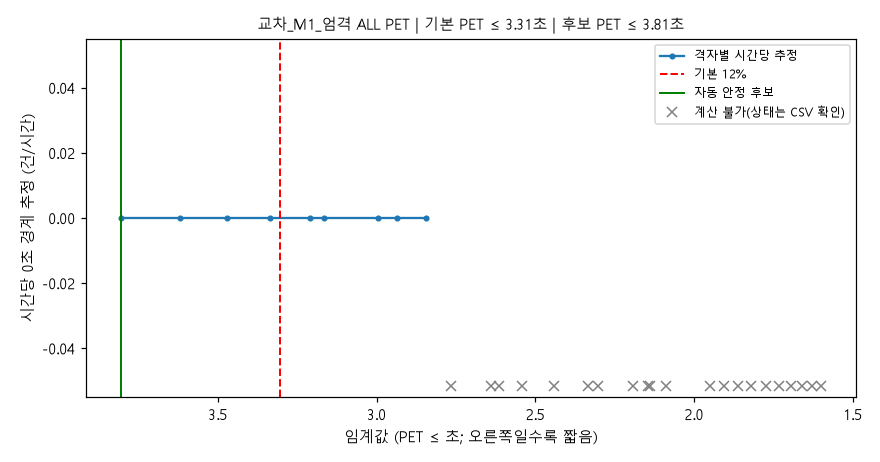

셀 8 경과: 219.87초


In [19]:
import time as _cell_time
_cell_started = _cell_time.perf_counter()
validate_threshold_overrides(strata)
started = time.perf_counter()
uni_rows_by_set = {key: [] for key in THRESHOLD_SETS}
thresholds_by_set = {key: {} for key in THRESHOLD_SETS}
candidate_rows, diagnostic_tables, sensitivity_tables = [], [], []
for (kind, site), table in strata.items():
    name = f"{kind}|{site}"
    for label, column in [("ttc", "x"), ("pet", "y")]:
        values = table[column].to_numpy(float)
        finite = values[np.isfinite(values)]
        identity = {"유형": kind, "지점": site, "지표": label}
        diagnostics = threshold_diagnostics(values)
        grid, fit_cache = diagnostics["grid"], diagnostics["fits"]
        candidate = stability_candidate(grid)
        diagnostic_tables.append(grid.assign(**identity))
        sensitivity = threshold_sensitivity(grid, hours.get(site, np.nan))
        sensitivity_tables.append(sensitivity.assign(**identity))
        u_default = float(np.quantile(finite, 1 - UPPER_SHARE)) if len(finite) else np.nan
        n_default = int(np.sum(finite > u_default))
        # A manual override must not overwrite the automatic default diagnostic.
        if n_default >= 10 and u_default not in fit_cache:
            fit_cache[u_default] = fit_gpd(finite[finite > u_default] - u_default)
        default_fit = fit_cache.get(u_default)
        candidate_row = {**identity, "n": len(finite), "u_default12": u_default,
                         "seconds_default12": -u_default, "n_exceed_default12": n_default,
                         "xi_default12": float(default_fit[0][1]) if default_fit is not None else np.nan,
                         **candidate}
        results_at_u = {}
        for threshold_set in THRESHOLD_SETS:
            rng = rng_by_threshold_set[threshold_set]
            u, source = select_threshold(name, label, threshold_set, u_default, candidate)
            candidate_row[f"u_applied_{threshold_set}"] = u
            candidate_row[f"source_{threshold_set}"] = source
            common = {**identity, "threshold_set": threshold_set, "threshold_source": source,
                      "hours": hours.get(site, np.nan), "threshold": u, "n": len(finite)}
            if not np.isfinite(u):
                uni_rows_by_set[threshold_set].append({**common, "fit": source,
                                                     "enough_exceedances": False})
                continue
            thresholds_by_set[threshold_set][(kind, site, label)] = u
            if u not in results_at_u:
                results_at_u[u] = univariate(values, u, fitted=fit_cache.get(u))
            result = results_at_u[u]
            overlap_values = table[column + "_overlap"].to_numpy(float)
            uni_rows_by_set[threshold_set].append({**common,
                "body_overlap_beyond_u": int(np.sum(overlap_values > u)), **result})
        candidate_rows.append(candidate_row)
        plot_threshold_diagnostics(grid, f"{kind} {site} {label.upper()}",
            RUN_DIR / "diagnostics" / f"{kind}_{site}_{label}.png", u_default, candidate,
            label.upper(), THRESHOLD_OVERRIDE.get(name, {}).get(label))
        plot_threshold_sensitivity(sensitivity, f"{kind} {site} {label.upper()}",
            RUN_DIR / "diagnostics" / f"{kind}_{site}_{label}_sensitivity.png", u_default, candidate,
            label.upper(), THRESHOLD_OVERRIDE.get(name, {}).get(label))

univariate_tables = {}
for threshold_set, uni_rows in uni_rows_by_set.items():
    table = pd.DataFrame(uni_rows)
    for col in ["expected_boundary_events", "expected_low", "expected_high"]:
        if col in table:
            table[col.replace("expected", "per_hour")] = table[col] / table["hours"]
    univariate_tables[threshold_set] = table
    save_csv(table, RUN_DIR / f"univariate_gpd_{threshold_set}.csv")
    print(threshold_set, "단변량 결과")
    display(table.loc[table["지점"].eq("ALL")].round(5))
univariate_table = univariate_tables["default12"]  # compatibility for downstream notebooks
thresholds = thresholds_by_set["default12"]
save_csv(univariate_table, RUN_DIR / "univariate_gpd.csv")
threshold_candidates = pd.DataFrame(candidate_rows)
save_csv(threshold_candidates, RUN_DIR / "threshold_candidates.csv")
save_csv(pd.concat(diagnostic_tables, ignore_index=True), RUN_DIR / "threshold_diagnostics.csv")
threshold_sensitivity_table = pd.concat(sensitivity_tables, ignore_index=True)
save_csv(threshold_sensitivity_table, RUN_DIR / "threshold_sensitivity.csv")
print("ALL 자동 후보(수동 적용 여부와 별도)")
display(threshold_candidates.loc[threshold_candidates["지점"].eq("ALL")].round(5))
site_candidates = threshold_candidates.loc[threshold_candidates["지점"].ne("ALL")].copy()
site_candidates["안정후보있음"] = site_candidates["status"].eq("stable")
site_summary = site_candidates.groupby(["유형", "지표"], as_index=False).agg(
    지점수=("지점", "nunique"), 안정후보_지점수=("안정후보있음", "sum"))
print("지점별 요약(ALL 제외)")
display(site_summary)
print(f"진단·두 기준 단변량 적합 완료 ({time.perf_counter() - started:.0f}초)")
from IPython.display import Image as _Image
for kind in kinds:
    for label in ["ttc", "pet"]:
        path = RUN_DIR / "diagnostics" / f"{kind}_ALL_{label}.png"
        if path.exists():
            display(_Image(filename=str(path)))
        sensitivity_path = RUN_DIR / "diagnostics" / f"{kind}_ALL_{label}_sensitivity.png"
        if sensitivity_path.exists():
            display(_Image(filename=str(sensitivity_path)))
print(f"셀 8 경과: {_cell_time.perf_counter() - _cell_started:.2f}초")

## 9. 이변량 적합
TTC와 PET가 **모두 계산된 사건**만 씁니다. 이 조건 때문에 분석 모집단이 단변량보다 좁아지며(08 §5), 그 수를 함께 표시합니다. 임계값은 같은 층·같은 기준의 두 단변량 임계값을 씁니다(M1 §5.2). 자동 안정 후보가 한쪽이라도 없고 수동값도 없으면 적합하지 않습니다. 한쪽이라도 `no_stable_region`이면 `no_stable_threshold`, 그렇지 않고 비교점이 부족하면 `too_few_for_stability`로 남깁니다. 각 지표의 원인은 `threshold_status_x/y`에 함께 보존합니다. 이 두 상태는 지표쌍 개수 부족(`too_few`)과 다릅니다.

In [20]:
import time as _cell_time
_cell_started = _cell_time.perf_counter()
started = time.perf_counter()
bivariate_tables, uni_lookups = {}, {}
for threshold_set in THRESHOLD_SETS:
    rng = rng_by_threshold_set[threshold_set]
    bi_rows = []
    lookup = univariate_tables[threshold_set].set_index(["유형", "지점", "지표"])
    uni_lookups[threshold_set] = lookup
    active_thresholds = thresholds_by_set[threshold_set]
    for (kind, site), table in strata.items():
        pairs = table.loc[np.isfinite(table["x"]) & np.isfinite(table["y"])]
        key_x, key_y = (kind, site, "ttc"), (kind, site, "pet")
        common = {"유형": kind, "지점": site, "threshold_set": threshold_set,
                  "hours": hours.get(site, np.nan), "n_pairs": len(pairs)}
        rx, ry = lookup.loc[key_x], lookup.loc[key_y]
        common.update(threshold_status_x=rx["threshold_source"], threshold_status_y=ry["threshold_source"])
        if threshold_set == "stable" and any(r["fit"] == "no_stable_region" for r in (rx, ry)):
            bi_rows.append({**common, "fit": "no_stable_threshold"})
            continue
        if threshold_set == "stable" and any(r["fit"] == "too_few_for_stability" for r in (rx, ry)):
            bi_rows.append({**common, "fit": "too_few_for_stability"})
            continue
        if key_x not in active_thresholds or key_y not in active_thresholds or len(pairs) < 20:
            bi_rows.append({**common, "fit": "too_few"})
            continue
        ux, uy = active_thresholds[key_x], active_thresholds[key_y]
        start_x = (float(rx.get("sigma", 0.5)) if pd.notna(rx.get("sigma", np.nan)) else 0.5,
                   float(rx.get("xi", 0.0)) if pd.notna(rx.get("xi", np.nan)) else 0.0)
        start_y = (float(ry.get("sigma", 0.5)) if pd.notna(ry.get("sigma", np.nan)) else 0.5,
                   float(ry.get("xi", 0.0)) if pd.notna(ry.get("xi", np.nan)) else 0.0)
        result = bivariate(pairs, ux, uy, start_x, start_y)
        bi_rows.append({**common, "threshold_x": ux, "threshold_y": uy, **result})
    table = pd.DataFrame(bi_rows)
    for col in [c for c in table.columns if c.startswith("expected_")]:
        table[col.replace("expected_", "per_hour_")] = table[col] / table["hours"]
    bivariate_tables[threshold_set] = table
    save_csv(table, RUN_DIR / f"bivariate_logistic_gp_{threshold_set}.csv")
    print(threshold_set, "이변량 결과")
    display(table.loc[table["지점"].eq("ALL")].round(5))
bivariate_table = bivariate_tables["default12"]
uni_lookup = uni_lookups["default12"]
save_csv(bivariate_table, RUN_DIR / "bivariate_logistic_gp.csv")
print(f"이변량 적합 완료 ({time.perf_counter() - started:.0f}초)")
print(f"셀 9 경과: {_cell_time.perf_counter() - _cell_started:.2f}초")

C:\Users\123\AppData\Local\Temp\ipykernel_31364\369875800.py:118: RuntimeWarning: overflow encountered in exp
  alpha_draws = 1.0 / (1.0 + np.exp(-draws[:, 4]))
C:\Users\123\AppData\Local\Temp\ipykernel_31364\369875800.py:113: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  draws = rng.multivariate_normal(best.x, cov, size=N_SIMULATIONS)
C:\Users\123\AppData\Local\Temp\ipykernel_31364\3308399184.py:25: RuntimeWarning: invalid value encountered in scalar add
  value = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * h[i] * h[j])


default12 이변량 결과


,유형,지점,threshold_set,hours,n_pairs,threshold_status_x,threshold_status_y,threshold_x,threshold_y,n_exceed_x,...,per_hour_y,per_hour_or_independent,per_hour_or_low,per_hour_or_high,per_hour_x_low,per_hour_x_high,per_hour_y_low,per_hour_y_high,per_hour_or_independent_low,per_hour_or_independent_high
0,후미_기본,ALL,default12,137.21562,140569,default12,default12,-2.11302,-0.91102,16413.0,...,0.11613,0.12683,0.09472,0.16597,0.00598,0.01724,0.08501,0.15493,0.09490,0.16623
21,후미_기본_엄격,ALL,default12,137.21562,125201,default12,default12,-2.07969,-0.91849,14668.0,...,0.08881,0.08987,0.06368,0.12022,0.00040,0.00228,0.06275,0.11899,0.06371,0.12024
42,후미_기본_2DTTC,ALL,default12,137.21562,122161,default12,default12,-2.04257,-0.91102,14380.0,...,0.09741,0.10841,0.07906,0.14347,0.00624,0.01752,0.06906,0.13146,0.07928,0.14383
63,후미_전차로,ALL,default12,137.21562,221057,default12,default12,-2.08184,-0.91838,25752.0,...,0.18271,0.21637,0.17266,0.26529,0.02284,0.04658,0.14170,0.22970,0.17314,0.26605
84,교차_M1,ALL,default12,137.21562,671,default12,default12,-2.51624,-2.77137,81.0,...,0.00000,0.00000,0.00000,0.00001,0.00000,0.00000,0.00000,0.00000,0.00000,0.00001
104,교차_M1_엄격,ALL,default12,137.21562,526,default12,default12,-2.53761,-3.30542,63.0,...,0.00000,0.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\123\AppData\Local\Temp\ipykernel_31364\369875800.py:118: RuntimeWarning: overflow encountered in exp
  alpha_draws = 1.0 / (1.0 + np.exp(-draws[:, 4]))
C:\Users\123\AppData\Local\Temp\ipykernel_31364\369875800.py:113: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  draws = rng.multivariate_normal(best.x, cov, size=N_SIMULATIONS)


stable 이변량 결과


,유형,지점,threshold_set,hours,n_pairs,threshold_status_x,threshold_status_y,fit,threshold_x,threshold_y,...,per_hour_y,per_hour_or_independent,per_hour_or_low,per_hour_or_high,per_hour_x_low,per_hour_x_high,per_hour_y_low,per_hour_y_high,per_hour_or_independent_low,per_hour_or_independent_high
0,후미_기본,ALL,stable,137.21562,140569,no_stable_region,no_stable_region,no_stable_threshold,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,후미_기본_엄격,ALL,stable,137.21562,125201,no_stable_region,no_stable_region,no_stable_threshold,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,후미_기본_2DTTC,ALL,stable,137.21562,122161,no_stable_region,no_stable_region,no_stable_threshold,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,후미_전차로,ALL,stable,137.21562,221057,no_stable_region,no_stable_region,no_stable_threshold,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84,교차_M1,ALL,stable,137.21562,671,stable,stable,ok,-2.76155,-3.18366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104,교차_M1_엄격,ALL,stable,137.21562,526,stable,stable,ok_no_covariance,-2.87800,-3.80551,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


이변량 적합 완료 (192초)
셀 9 경과: 192.21초


## 10. 같은 대상끼리 나란히 비교
층마다 시간당 "0초 경계에 닿는 사건"의 추정값을 나란히 둡니다.
- `단변량_TTC` vs `이변량_주변_TTC`: 같은 대상(TTC가 0초에 닿음)을 단변량 모형과 이변량 모형이 각각 추정한 값. 단, 이변량은 두 지표가 모두 있는 사건만 쓰므로 모집단이 다릅니다.
- `이변량_OR` vs `독립결합_OR`: 같은 대상(둘 중 하나라도 0초)을, 의존성을 추정한 모형과 독립을 가정한 모형이 각각 추정한 값. 두 값의 차이가 **의존구조 모델링이 더하는 부분**입니다.
- 구간(95%)이 넓으면 그 층의 결과는 결론을 뒷받침하기 어렵습니다. **사고자료가 없으므로 어느 쪽이 더 정확한지는 판정하지 않습니다.**
- 같은 유형·지점의 `comparison_per_hour_default12.csv`와 `comparison_per_hour_stable.csv`를 비교하세요. 임계값·초과 수·형상 ξ가 어떻게 달라졌는지 후보표와 함께 확인합니다. 안정 후보가 없는 결과는 빈 값과 상태로 남깁니다. 두 기준의 차이는 임계값 선택에 대한 민감도이며 정확도 우위가 아닙니다.
- 기준 없는 기존 파일명(`univariate_gpd.csv`, `bivariate_logistic_gp.csv`, `comparison_per_hour.csv`)은 `default12` 파일과 같은 내용입니다. 수동값을 지정했다면 이름이 default12여도 실제 적용값은 수동값입니다.

In [21]:
import time as _cell_time
_cell_started = _cell_time.perf_counter()
comparison_tables = {}
for threshold_set in THRESHOLD_SETS:
    rows = []
    lookup = uni_lookups[threshold_set]
    bi_table = bivariate_tables[threshold_set]
    for (kind, site) in strata:
        uni_t = lookup.loc[(kind, site, "ttc")] if (kind, site, "ttc") in lookup.index else None
        uni_p = lookup.loc[(kind, site, "pet")] if (kind, site, "pet") in lookup.index else None
        bi = bi_table.loc[bi_table["유형"].eq(kind) & bi_table["지점"].eq(site)]
        bi = bi.iloc[0] if len(bi) else None
        h = hours.get(site, np.nan)

        def per_hour(row, col):
            return float(row[col]) / h if row is not None and col in row and pd.notna(row[col]) else np.nan

        rows.append({"유형": kind, "지점": site, "threshold_set": threshold_set,
                     "fit_ttc": uni_t["fit"], "fit_pet": uni_p["fit"], "fit_bivariate": bi["fit"],
                     "단변량_TTC": per_hour(uni_t, "expected_boundary_events"),
                     "단변량_PET": per_hour(uni_p, "expected_boundary_events"),
                     "이변량_주변_TTC": per_hour(bi, "expected_x"), "이변량_주변_PET": per_hour(bi, "expected_y"),
                     "이변량_OR": per_hour(bi, "expected_or"), "독립결합_OR": per_hour(bi, "expected_or_independent"),
                     "이변량_OR_하한": per_hour(bi, "expected_or_low"), "이변량_OR_상한": per_hour(bi, "expected_or_high"),
                     "alpha": float(bi["alpha"]) if bi is not None and "alpha" in bi and pd.notna(bi["alpha"]) else np.nan,
                     "TTC초과충분": bool(uni_t["enough_exceedances"]) if uni_t is not None and pd.notna(uni_t.get("enough_exceedances")) else False,
                     "PET초과충분": bool(uni_p["enough_exceedances"]) if uni_p is not None and pd.notna(uni_p.get("enough_exceedances")) else False})
    table = pd.DataFrame(rows)
    comparison_tables[threshold_set] = table
    save_csv(table, RUN_DIR / f"comparison_per_hour_{threshold_set}.csv")
    print(threshold_set, "시간당 비교")
    display(table.loc[table["지점"].eq("ALL")].round(6))
    display(table.loc[table["지점"].ne("ALL") & table["유형"].eq("교차_M1")].round(6))
comparison = comparison_tables["default12"]
save_csv(comparison, RUN_DIR / "comparison_per_hour.csv")
print("시간당 0초 경계 도달 추정(외삽) — 사고 건수가 아님")
print(f"셀 10 경과: {_cell_time.perf_counter() - _cell_started:.2f}초")

default12 시간당 비교


,유형,지점,threshold_set,fit_ttc,fit_pet,fit_bivariate,단변량_TTC,단변량_PET,이변량_주변_TTC,이변량_주변_PET,이변량_OR,독립결합_OR,이변량_OR_하한,이변량_OR_상한,alpha,TTC초과충분,PET초과충분
0,후미_기본,ALL,default12,ok,ok,ok,0.036853,0.255862,0.010705,0.116131,0.126605,0.126835,0.094718,0.165966,0.993711,True,True
21,후미_기본_엄격,ALL,default12,ok,ok,ok,0.008687,0.244380,0.001063,0.088806,0.089842,0.089869,0.063685,0.120219,0.995391,True,True
42,후미_기본_2DTTC,ALL,default12,ok,ok,ok,0.027064,0.255862,0.011002,0.097414,0.108106,0.108415,0.079055,0.143469,0.991269,True,True
63,후미_전차로,ALL,default12,ok,ok,ok,0.093932,0.411600,0.033664,0.182707,0.215778,0.216367,0.172657,0.265286,0.993683,True,True
84,교차_M1,ALL,default12,ok,ok,ok,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000012,0.896890,True,True
104,교차_M1_엄격,ALL,default12,ok,ok,ok_no_covariance,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,1.000000,True,True


,유형,지점,threshold_set,fit_ttc,fit_pet,fit_bivariate,단변량_TTC,단변량_PET,이변량_주변_TTC,이변량_주변_PET,이변량_OR,독립결합_OR,이변량_OR_하한,이변량_OR_상한,alpha,TTC초과충분,PET초과충분
85,교차_M1,A,default12,too_few,too_few,too_few,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
86,교차_M1,B,default12,ok_no_covariance,ok,ok_no_covariance,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.891534,False,False
87,교차_M1,C,default12,too_few,too_few,too_few,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
88,교차_M1,F,default12,too_few,too_few,too_few,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
89,교차_M1,G,default12,too_few,too_few,too_few,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
90,교차_M1,H,default12,too_few,too_few,too_few,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
91,교차_M1,I,default12,too_few,too_few,too_few,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
92,교차_M1,J,default12,too_few,too_few,too_few,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
93,교차_M1,K,default12,too_few,too_few,too_few,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
94,교차_M1,L,default12,ok,ok_no_covariance,ok_no_covariance,0.023844,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.936862,False,False


stable 시간당 비교


,유형,지점,threshold_set,fit_ttc,fit_pet,fit_bivariate,단변량_TTC,단변량_PET,이변량_주변_TTC,이변량_주변_PET,이변량_OR,독립결합_OR,이변량_OR_하한,이변량_OR_상한,alpha,TTC초과충분,PET초과충분
0,후미_기본,ALL,stable,no_stable_region,no_stable_region,no_stable_threshold,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
21,후미_기본_엄격,ALL,stable,no_stable_region,no_stable_region,no_stable_threshold,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
42,후미_기본_2DTTC,ALL,stable,no_stable_region,no_stable_region,no_stable_threshold,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
63,후미_전차로,ALL,stable,no_stable_region,no_stable_region,no_stable_threshold,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
84,교차_M1,ALL,stable,ok,ok,ok,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.924687,True,True
104,교차_M1_엄격,ALL,stable,ok,ok,ok_no_covariance,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.000000,True,True


,유형,지점,threshold_set,fit_ttc,fit_pet,fit_bivariate,단변량_TTC,단변량_PET,이변량_주변_TTC,이변량_주변_PET,이변량_OR,독립결합_OR,이변량_OR_하한,이변량_OR_상한,alpha,TTC초과충분,PET초과충분
85,교차_M1,A,stable,too_few_for_stability,too_few_for_stability,too_few_for_stability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
86,교차_M1,B,stable,too_few_for_stability,too_few_for_stability,too_few_for_stability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
87,교차_M1,C,stable,too_few_for_stability,too_few_for_stability,too_few_for_stability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
88,교차_M1,F,stable,too_few_for_stability,too_few_for_stability,too_few_for_stability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
89,교차_M1,G,stable,too_few_for_stability,too_few_for_stability,too_few_for_stability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
90,교차_M1,H,stable,too_few_for_stability,too_few_for_stability,too_few_for_stability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
91,교차_M1,I,stable,too_few_for_stability,too_few_for_stability,too_few_for_stability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
92,교차_M1,J,stable,too_few_for_stability,too_few_for_stability,too_few_for_stability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
93,교차_M1,K,stable,too_few_for_stability,too_few_for_stability,too_few_for_stability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
94,교차_M1,L,stable,too_few_for_stability,too_few_for_stability,too_few_for_stability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False


시간당 0초 경계 도달 추정(외삽) — 사고 건수가 아님
셀 10 경과: 0.18초


## 11. 저장

In [22]:
import time as _cell_time
_cell_started = _cell_time.perf_counter()
run_metadata.update(status="completed", finished_at_utc=now_utc(),
                    n_strata=len(strata), n_univariate_fits=int(univariate_table["fit"].astype(str).str.startswith("ok").sum()),
                    n_bivariate_fits=int(bivariate_table["fit"].astype(str).str.startswith("ok").sum()))
run_metadata["fits_by_threshold_set"] = {
    key: {"univariate": int(univariate_tables[key]["fit"].str.startswith("ok").sum()),
          "bivariate": int(bivariate_tables[key]["fit"].str.startswith("ok").sum())}
    for key in THRESHOLD_SETS}
save_json(run_metadata, RUN_DIR / "run_metadata.json")
print(json.dumps({"실행_ID": RUN_ID, "결과폴더": str(RUN_DIR), "층": len(strata),
                  "단변량적합": run_metadata["n_univariate_fits"], "이변량적합": run_metadata["n_bivariate_fits"],
                  "주의": "사고자료 대조 없음 — 정확도 판정이 아니라 추정 차이·불확실성"}, ensure_ascii=False, indent=2))
print("노트북을 저장하세요.")
print(f"셀 11 경과: {_cell_time.perf_counter() - _cell_started:.2f}초")

{
  "실행_ID": "20260924T191302Z_4491ed18",
  "결과폴더": "C:\\Users\\123\\Documents\\(송도) 교통 연구 논문\\data\\processed\\songdo_evt\\20260924T191302Z_4491ed18",
  "층": 124,
  "단변량적합": 179,
  "이변량적합": 89,
  "주의": "사고자료 대조 없음 — 정확도 판정이 아니라 추정 차이·불확실성"
}
노트북을 저장하세요.
셀 11 경과: 0.00초
